# Machine-Learning Demand Forecasting for Working-Capital Optimization

**Capstone research question:** Can machine-learning-driven demand forecasting improve working-capital efficiency by optimizing inventory levels while maintaining service levels?

This notebook uses two public Walmart datasets:

1. **M5 Forecasting—Accuracy** (daily unit demand, calendar/events/SNAP, and prices), used for the main daily forecasting and inventory simulation.
2. **Walmart Recruiting—Store Sales Forecasting** (weekly sales, holidays, markdowns, CPI, unemployment, temperature, fuel price, and store metadata), used as a secondary robustness analysis.

The two sources are intentionally **not row-joined**: they cover different periods, grains, targets, and identifiers. The same leakage-safe modeling framework is applied to each, and conclusions are compared.




## 1. Business framing and hypotheses

Inventory consumes working capital. Too much inventory raises cash tied up, holding cost, and Days Inventory Outstanding (DIO); too little inventory creates lost sales and weak service. The project therefore connects forecast quality to operational outcomes instead of stopping at model error.

**Primary hypothesis:** a tuned model using lag, rolling, calendar, price, event, and promotion signals will improve WAPE over a seasonal-naive forecast.

**Operational hypothesis:** using the improved forecast in a lead-time base-stock policy will reduce average inventory/working capital without materially reducing fill rate or cycle-service level.

**Units of analysis:** an aggregate M5 store/category daily series and an aggregate Walmart weekly series. This keeps runtime practical while preserving temporal structure. Configuration below lets the reader change the slice or item count.

**Success criteria:**

- Forecasting: lower MAE, RMSE, WAPE, sMAPE, and MASE; higher forecast accuracy (100 − WAPE) and $R^2$.
- Stockout-risk classification: accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrix. Recall is emphasized because missed stockout risks are costly.
- Inventory: higher fill rate/service level, fewer stockout periods, lower average inventory, lower working capital, and lower DIO.


## 2. Data acquisition and expected directory structure

Download the competition files from Kaggle and place them as shown. Kaggle authentication/competition-rule acceptance may be required.

```text
data/
├── m5/
│   ├── sales_train_validation.csv   # or sales_train_evaluation.csv
│   ├── calendar.csv
│   └── sell_prices.csv
└── walmart/
    ├── train.csv
    ├── features.csv
    └── stores.csv
```


```




In [1]:
####%pip install --upgrade statsmodels xgboost-cpu prophet tensorflow shap

In [2]:
###%pip install --upgrade joblib scikit-learn

In [3]:
# Core imports and reproducibility
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "2"


from pathlib import Path
import math, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels
import xgboost
import prophet
import tensorflow as tf
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_validate
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier,
    HistGradientBoostingRegressor, HistGradientBoostingClassifier,
    GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
)
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

DATA_ROOT = Path("data")
M5_DIR = DATA_ROOT / "m5"
WALMART_DIR = DATA_ROOT / "walmart"

# Practical defaults. Increase M5_MAX_ITEMS or set to None for a larger study.
M5_STORE = "CA_1"
M5_CATEGORY = "FOODS"
M5_MAX_ITEMS = 500
M5_TEST_DAYS = 56
WALMART_TEST_WEEKS = 16
RUN_HEAVY_MODELS = True      # Prophet, SARIMAX, LSTM, XGBoost if installed
RUN_TUNING = True
N_SEARCH_ITER = 10
N_JOBS = 2


## 3. Reusable validation and evaluation functions


In [4]:
def wape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.abs(y_true).sum()
    return np.abs(y_true - y_pred).sum() / denom if denom else np.nan


def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(np.divide(2 * np.abs(y_true-y_pred), denom,
                             out=np.zeros_like(denom, dtype=float), where=denom != 0))


def mase(y_true, y_pred, y_train, seasonality=1):
    y_train = np.asarray(y_train)
    scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))
    return mean_absolute_error(y_true, y_pred) / scale if scale else np.nan


def regression_metrics(name, y_true, y_pred, y_train, seasonality, fit_seconds=np.nan):
    pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    wp = wape(y_true, pred)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "WAPE": wp,
        "forecast_accuracy_pct": 100 * (1 - wp),
        "sMAPE": smape(y_true, pred),
        "MASE": mase(y_true, pred, y_train, seasonality),
        "R2": r2_score(y_true, pred),
        "fit_seconds": fit_seconds,
    }


def chronological_split(frame, test_size):
    if len(frame) <= test_size + 30:
        raise ValueError(f"Need more than {test_size + 30} usable rows; found {len(frame)}")
    return frame.iloc[:-test_size].copy(), frame.iloc[-test_size:].copy()


def assert_no_temporal_leakage(train, test, date_col="date"):
    assert train[date_col].max() < test[date_col].min(), "Train/test dates overlap."
    print("Leakage check passed:", train[date_col].max().date(), "<", test[date_col].min().date())


## 4. Load and aggregate the M5 data


In [5]:
def require_files(directory, names):
    missing = [name for name in names if not (directory / name).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing {missing} in {directory.resolve()}. "
            "Download/unzip the Kaggle files using the instructions above."
        )


def load_m5(m5_dir=M5_DIR, store=M5_STORE, category=M5_CATEGORY, max_items=M5_MAX_ITEMS):
    sales_name = "sales_train_evaluation.csv" if (m5_dir / "sales_train_evaluation.csv").exists() else "sales_train_validation.csv"
    require_files(m5_dir, [sales_name, "calendar.csv", "sell_prices.csv"])
    sales = pd.read_csv(m5_dir / sales_name)
    calendar = pd.read_csv(m5_dir / "calendar.csv", parse_dates=["date"])
    prices = pd.read_csv(m5_dir / "sell_prices.csv")

    subset = sales.query("store_id == @store and cat_id == @category").copy()
    if subset.empty:
        raise ValueError(f"No M5 rows for store={store!r}, category={category!r}")
    if max_items is not None and len(subset) > max_items:
        # Deterministic sample; aggregate series is a computationally manageable case study.
        subset = subset.sample(max_items, random_state=SEED)

    d_cols = [c for c in subset.columns if c.startswith("d_")]
    demand = subset[d_cols].sum(axis=0).rename("demand").rename_axis("d").reset_index()
    keep_cal = ["d", "date", "wm_yr_wk", "wday", "month", "year",
                "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]
    daily = demand.merge(calendar[keep_cal], on="d", how="left")

    item_ids = subset["item_id"].unique()
    weekly_price = (prices.loc[(prices.store_id == store) & prices.item_id.isin(item_ids)]
                    .groupby("wm_yr_wk", as_index=False)["sell_price"]
                    .agg(avg_sell_price="mean", price_dispersion="std"))
    daily = daily.merge(weekly_price, on="wm_yr_wk", how="left")
    state = store.split("_")[0]
    daily["snap"] = daily.get(f"snap_{state}", 0).fillna(0).astype(int)
    daily["event_name_1"] = daily["event_name_1"].fillna("None")
    daily["event_type_1"] = daily["event_type_1"].fillna("None")
    daily["avg_sell_price"] = daily["avg_sell_price"].ffill().bfill()
    daily["price_dispersion"] = daily["price_dispersion"].fillna(0)
    daily["source"] = "M5"
    return daily.sort_values("date").reset_index(drop=True), subset


m5, m5_items = load_m5()
print(f"M5 rows: {len(m5):,}; sampled items: {len(m5_items):,}; dates: {m5.date.min().date()} to {m5.date.max().date()}")
display(m5.head(2))


M5 rows: 1,941; sampled items: 500; dates: 2011-01-29 to 2016-05-22


,d,demand,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,avg_sell_price,price_dispersion,snap,source
0,d_1,1262,2011-01-29,11101,1,1,2011,None,None,0,0,0,3.126239,2.045004,0,M5
1,d_2,1200,2011-01-30,11101,2,1,2011,None,None,0,0,0,3.126239,2.045004,0,M5


## 5. M5 data quality and exploratory analysis


In [6]:
quality = pd.DataFrame({
    "dtype": m5.dtypes.astype(str),
    "missing_n": m5.isna().sum(),
    "missing_pct": 100 * m5.isna().mean(),
    "n_unique": m5.nunique(dropna=False)
}).sort_values("missing_pct", ascending=False)
display(quality)
assert m5["date"].is_monotonic_increasing
assert not m5["date"].duplicated().any()
print("Demand summary")
display(m5["demand"].describe(percentiles=[.01, .25, .5, .75, .95, .99]).to_frame().T)


,dtype,missing_n,missing_pct,n_unique
d,object,0,0.0,1941
demand,int64,0,0.0,812
date,datetime64[ns],0,0.0,1941
wm_yr_wk,int64,0,0.0,278
wday,int64,0,0.0,7
month,int64,0,0.0,12
year,int64,0,0.0,6
event_name_1,object,0,0.0,31
event_type_1,object,0,0.0,5
snap_CA,int64,0,0.0,2


Demand summary


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
demand,1941.0,990.708913,247.211966,0.0,528.0,815.0,955.0,1148.0,1434.0,1590.6,1843.0


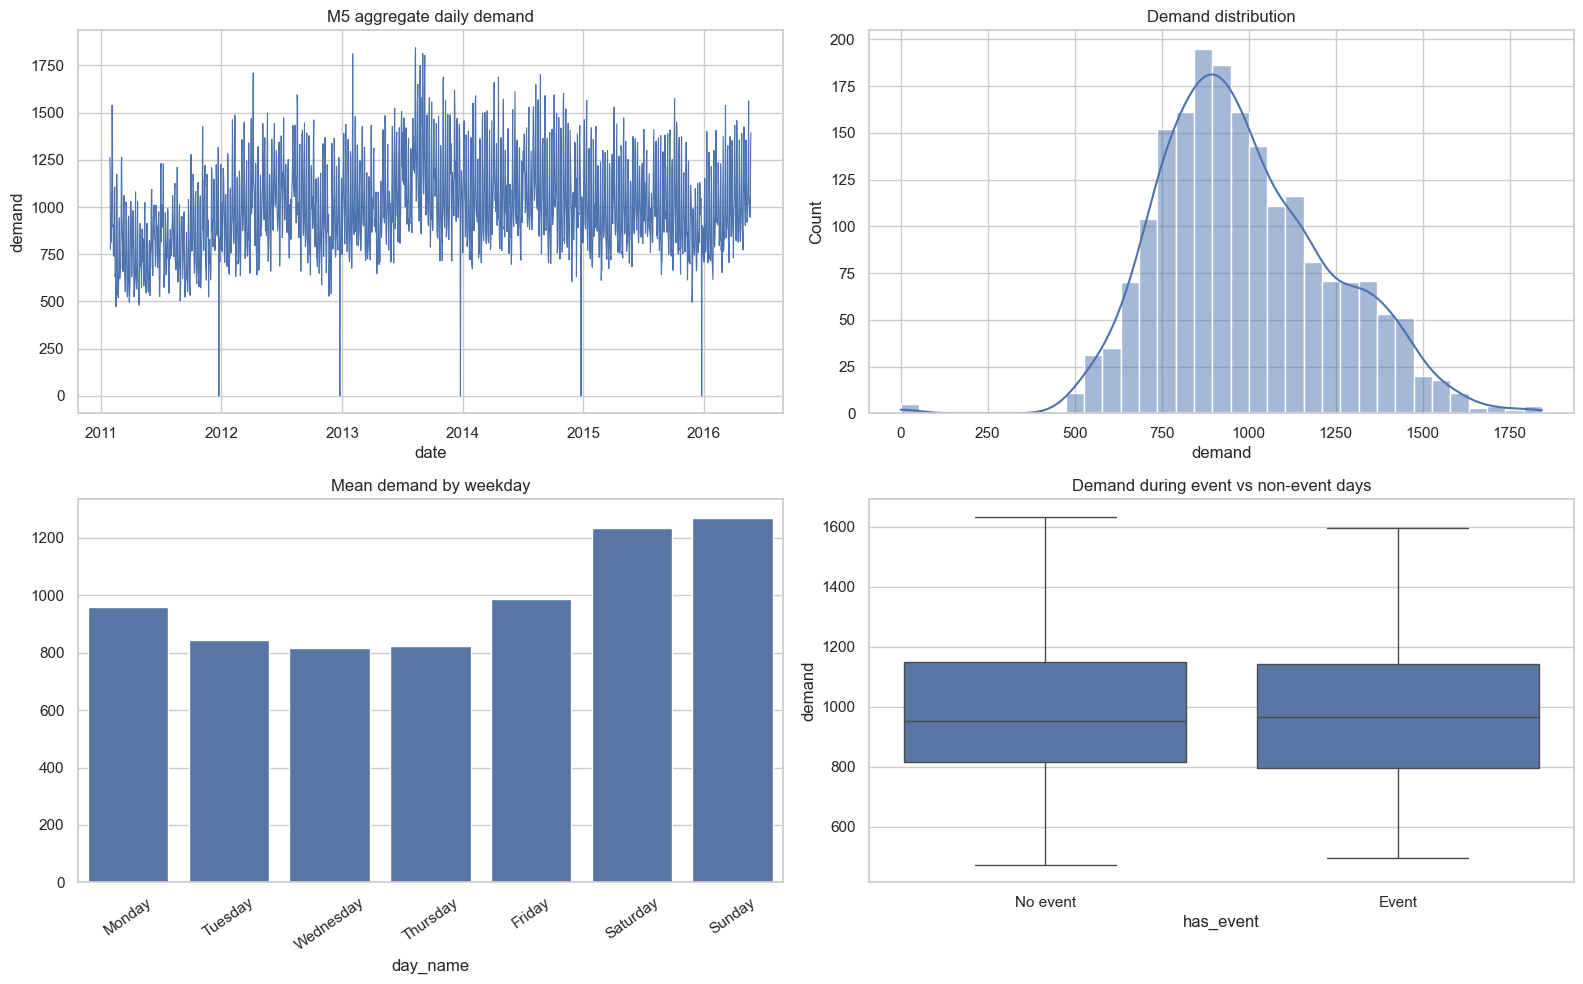

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(data=m5, x="date", y="demand", ax=axes[0,0], linewidth=.8)
axes[0,0].set_title("M5 aggregate daily demand")
sns.histplot(m5["demand"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Demand distribution")
weekday = m5.assign(day_name=m5.date.dt.day_name()).groupby("day_name")["demand"].mean()
weekday = weekday.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
sns.barplot(x=weekday.index, y=weekday.values, ax=axes[1,0])
axes[1,0].tick_params(axis="x", rotation=35); axes[1,0].set_title("Mean demand by weekday")
event = m5.assign(has_event=np.where(m5.event_name_1.eq("None"), "No event", "Event"))
sns.boxplot(data=event, x="has_event", y="demand", showfliers=False, ax=axes[1,1])
axes[1,1].set_title("Demand during event vs non-event days")
plt.tight_layout(); plt.show()


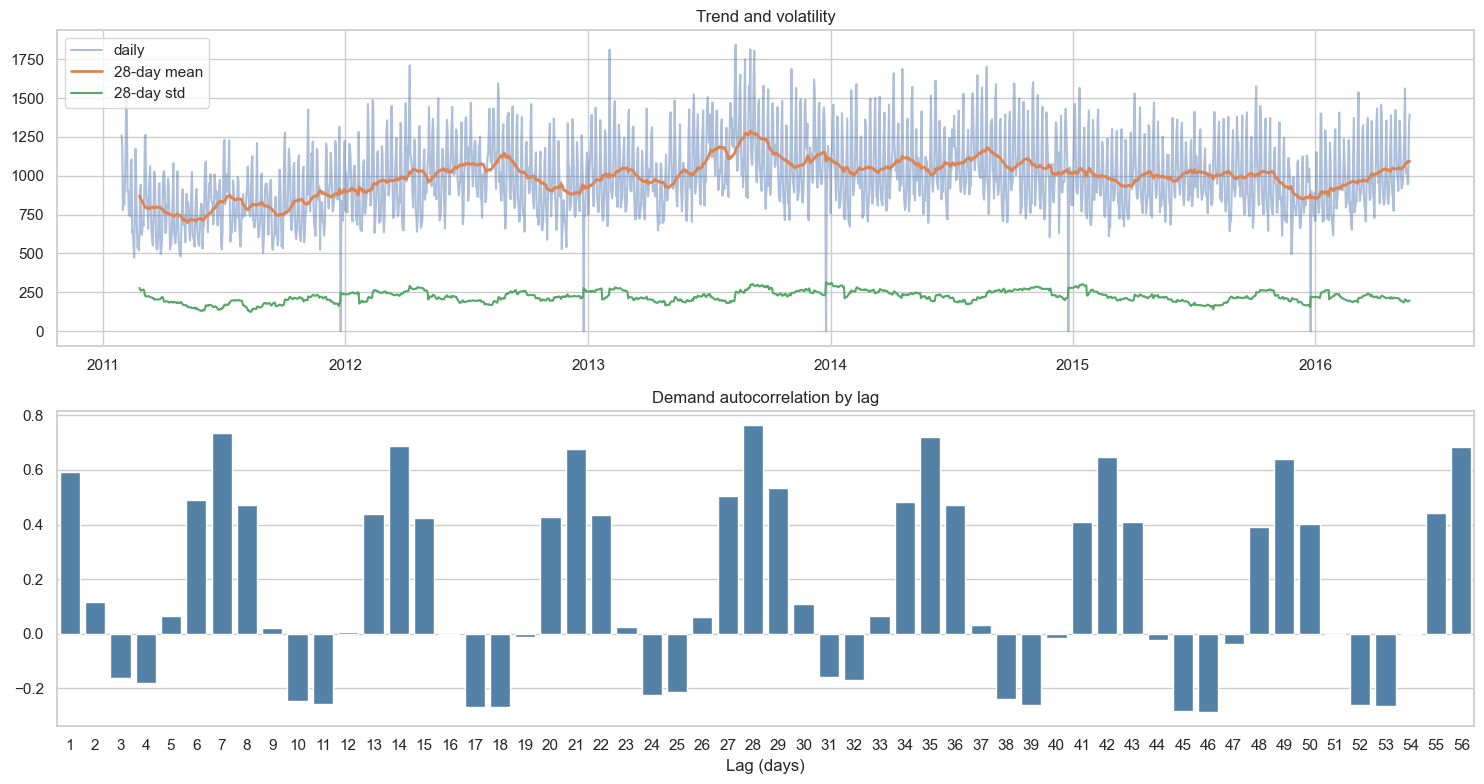

In [8]:
# Rolling behavior and autocorrelation (lag correlations are descriptive, not model validation).
eda = m5.set_index("date")["demand"]
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(eda, alpha=.45, label="daily")
axes[0].plot(eda.rolling(28).mean(), label="28-day mean", linewidth=2)
axes[0].plot(eda.rolling(28).std(), label="28-day std", linewidth=1.5)
axes[0].legend(); axes[0].set_title("Trend and volatility")
lags = np.arange(1, 57)
ac = [eda.autocorr(int(l)) for l in lags]
sns.barplot(x=lags, y=ac, ax=axes[1], color="steelblue")
axes[1].set_title("Demand autocorrelation by lag"); axes[1].set_xlabel("Lag (days)")
plt.tight_layout(); plt.show()


## 6. Leakage-safe feature engineering


In [9]:
def make_time_features(df, target="demand", frequency="daily"):
    out = df.sort_values("date").copy()
    out["dow"] = out.date.dt.dayofweek
    out["weekofyear"] = out.date.dt.isocalendar().week.astype(int)
    out["quarter"] = out.date.dt.quarter
    out["dayofyear"] = out.date.dt.dayofyear
    out["is_month_start"] = out.date.dt.is_month_start.astype(int)
    out["is_month_end"] = out.date.dt.is_month_end.astype(int)
    out["sin_dow"] = np.sin(2*np.pi*out["dow"]/7)
    out["cos_dow"] = np.cos(2*np.pi*out["dow"]/7)
    out["sin_year"] = np.sin(2*np.pi*out["dayofyear"]/365.25)
    out["cos_year"] = np.cos(2*np.pi*out["dayofyear"]/365.25)

    if frequency == "daily":
        lags, windows = [1, 7, 14, 28, 56], [7, 14, 28, 56]
    else:
        lags, windows = [1, 2, 4, 13, 26, 52], [4, 8, 13, 26]
    for lag in lags:
        out[f"lag_{lag}"] = out[target].shift(lag)
    # shift(1) is essential: rolling statistics never include the row being predicted.
    shifted = out[target].shift(1)
    for window in windows:
        out[f"roll_mean_{window}"] = shifted.rolling(window).mean()
        out[f"roll_std_{window}"] = shifted.rolling(window).std()
        out[f"roll_min_{window}"] = shifted.rolling(window).min()
        out[f"roll_max_{window}"] = shifted.rolling(window).max()
    if "avg_sell_price" in out:
        out["price_change_1"] = out.avg_sell_price.pct_change().replace([np.inf,-np.inf], np.nan)
        out["price_vs_28d"] = out.avg_sell_price / out.avg_sell_price.shift(1).rolling(28).mean() - 1
    return out.dropna().reset_index(drop=True)


m5_model = make_time_features(m5, target="demand", frequency="daily")
m5_train, m5_test = chronological_split(m5_model, M5_TEST_DAYS)
assert_no_temporal_leakage(m5_train, m5_test)
print(m5_train.shape, m5_test.shape)


Leakage check passed: 2016-03-27 < 2016-03-28
(1829, 49) (56, 49)


## 7. M5 model benchmark, time-series cross-validation, and tuning

Random shuffling is inappropriate for forecasting because it leaks future regimes into training. The final holdout is the last 56 days; tuning uses expanding-window `TimeSeriesSplit` only within the training period.


In [10]:
M5_DROP = ["date", "d", "demand", "source", "wm_yr_wk", "year"]
m5_features = [c for c in m5_model.columns if c not in M5_DROP]
X_train, y_train = m5_train[m5_features], m5_train["demand"]
X_test, y_test = m5_test[m5_features], m5_test["demand"]

categorical = [c for c in X_train.columns if X_train[c].dtype == "object"]
numeric = [c for c in X_train.columns if c not in categorical]
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical)
], remainder="drop")

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=.05, max_iter=10000, random_state=SEED),
    "ElasticNet": ElasticNet(alpha=.05, l1_ratio=.25, max_iter=10000, random_state=SEED),
    "RandomForest": RandomForestRegressor(n_estimators=350, min_samples_leaf=2, max_features=.8,
                                           random_state=SEED, n_jobs=N_JOBS),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=350, min_samples_leaf=2, max_features=.9,
                                       random_state=SEED, n_jobs=N_JOBS),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=250, learning_rate=.04,
                                                    max_depth=3, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=350, learning_rate=.05,
                                                           l2_regularization=1.0, random_state=SEED)
}

fitted_models, predictions, rows = {}, {}, []
seasonal_pred = m5_test["lag_7"].to_numpy()
predictions["SeasonalNaive_7"] = seasonal_pred
rows.append(regression_metrics("SeasonalNaive_7", y_test, seasonal_pred, y_train, 7, 0))

for name, estimator in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("model", estimator)])
    start = time.perf_counter(); pipe.fit(X_train, y_train); elapsed = time.perf_counter()-start
    pred = np.clip(pipe.predict(X_test), 0, None)
    fitted_models[name], predictions[name] = pipe, pred
    rows.append(regression_metrics(name, y_test, pred, y_train, 7, elapsed))

m5_results = pd.DataFrame(rows).sort_values("WAPE").reset_index(drop=True)
display(m5_results.round({"MAE":2,"RMSE":2,"WAPE":3,"forecast_accuracy_pct":1,
                          "sMAPE":3,"MASE":3,"R2":3,"fit_seconds":2}))


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,Lasso,58.98,76.78,0.055,94.5,0.056,0.432,0.861,0.04
1,LinearRegression,59.37,76.67,0.056,94.4,0.057,0.434,0.862,0.03
2,Ridge,60.43,78.16,0.057,94.3,0.058,0.442,0.856,0.02
3,ElasticNet,61.93,80.82,0.058,94.2,0.059,0.453,0.846,0.03
4,GradientBoosting,63.11,80.47,0.059,94.1,0.061,0.462,0.847,3.05
5,RandomForest,64.20,81.72,0.060,94.0,0.061,0.470,0.843,3.66
6,ExtraTrees,68.34,83.39,0.064,93.6,0.066,0.500,0.836,2.59
7,HistGradientBoosting,69.04,86.67,0.065,93.5,0.066,0.505,0.823,1.59
8,SeasonalNaive_7,100.14,130.08,0.094,90.6,0.095,0.733,0.602,0.00


In [11]:
# Time-aware hyperparameter search for the strongest practical tree model.
if RUN_TUNING:
    tscv = TimeSeriesSplit(n_splits=4)
    rf_pipe = Pipeline([("prep", clone(preprocess)),
                        ("model", RandomForestRegressor(random_state=SEED, n_jobs=N_JOBS))])
    rf_space = {
        "model__n_estimators": [250, 400, 600],
        "model__max_depth": [None, 8, 14, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": [.5, .8, 1.0]
    }
    search = RandomizedSearchCV(rf_pipe, rf_space, n_iter=N_SEARCH_ITER,
                                scoring="neg_mean_absolute_error", cv=tscv,
                                random_state=SEED, n_jobs=N_JOBS, verbose=1)
    start = time.perf_counter(); search.fit(X_train, y_train); elapsed = time.perf_counter()-start
    tuned_pred = np.clip(search.best_estimator_.predict(X_test), 0, None)
    fitted_models["TunedRandomForest"] = search.best_estimator_
    predictions["TunedRandomForest"] = tuned_pred
    m5_results = m5_results.loc[m5_results.model.ne("TunedRandomForest")].copy()
    m5_results = pd.concat([m5_results, pd.DataFrame([
        regression_metrics("TunedRandomForest", y_test, tuned_pred, y_train, 7, elapsed)
    ])], ignore_index=True).sort_values("WAPE").reset_index(drop=True)
    print("Best parameters:", search.best_params_)
    display(m5_results)


Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters: {'model__n_estimators': 250, 'model__min_samples_leaf': 1, 'model__max_features': 0.8, 'model__max_depth': None}


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,Lasso,58.983693,76.784641,0.055323,94.467747,0.056475,0.431525,0.861145,0.039928
1,LinearRegression,59.367546,76.666860,0.055683,94.431745,0.056970,0.434333,0.861570,0.025202
2,Ridge,60.429502,78.162650,0.056679,94.332141,0.057630,0.442103,0.856116,0.017623
3,ElasticNet,61.929322,80.823747,0.058085,94.191468,0.058854,0.453075,0.846152,0.026448
4,GradientBoosting,63.114421,80.474475,0.059197,94.080314,0.060951,0.461745,0.847479,3.053090
5,RandomForest,64.201249,81.716298,0.060216,93.978378,0.061196,0.469697,0.842735,3.662778
6,TunedRandomForest,64.723429,82.288794,0.060706,93.929401,0.061811,0.473517,0.840524,41.569462
7,ExtraTrees,68.336973,83.389574,0.064095,93.590476,0.065567,0.499954,0.836229,2.591735
8,HistGradientBoosting,69.042584,86.667608,0.064757,93.524295,0.066077,0.505116,0.823100,1.590864
9,SeasonalNaive_7,100.142857,130.076214,0.093927,90.607309,0.095139,0.732646,0.601517,0.000000


### 7.1 Explicit GridSearchCV with time-aware folds

The rubric explicitly requests grid-search hyperparameter tuning. Ridge is used here because its compact, ordered hyperparameter grid can be evaluated exhaustively and quickly. The same expanding-window `TimeSeriesSplit` prevents future observations from entering earlier training folds. The selection metric is MAE because it is expressed in demand units and is less dominated by a few large errors than RMSE.


Best Ridge parameters: {'model__alpha': 100.0}
Best expanding-window CV MAE: 86.36


,alpha,mean_cv_MAE,std_cv_MAE
0,0.01,90.480,16.188
1,0.10,90.560,16.398
2,1.00,90.811,17.146
3,5.00,89.791,15.774
4,10.00,88.715,13.805
5,25.00,87.322,10.572
6,50.00,86.530,8.637
7,100.00,86.357,7.469


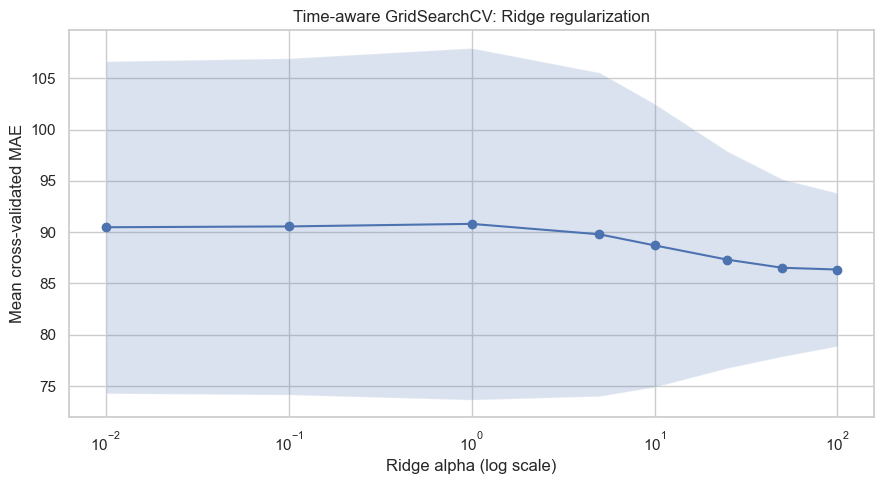

,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,Lasso,58.984,76.785,0.055,94.468,0.056,0.432,0.861,0.040
1,LinearRegression,59.368,76.667,0.056,94.432,0.057,0.434,0.862,0.025
2,Ridge,60.430,78.163,0.057,94.332,0.058,0.442,0.856,0.018
3,ElasticNet,61.929,80.824,0.058,94.191,0.059,0.453,0.846,0.026
4,GridSearch_Ridge,62.306,81.408,0.058,94.156,0.059,0.456,0.844,0.476
5,GradientBoosting,63.114,80.474,0.059,94.080,0.061,0.462,0.847,3.053
6,RandomForest,64.201,81.716,0.060,93.978,0.061,0.470,0.843,3.663
7,TunedRandomForest,64.723,82.289,0.061,93.929,0.062,0.474,0.841,41.569
8,ExtraTrees,68.337,83.390,0.064,93.590,0.066,0.500,0.836,2.592
9,HistGradientBoosting,69.043,86.668,0.065,93.524,0.066,0.505,0.823,1.591


In [12]:
from sklearn.model_selection import GridSearchCV

grid_model_name = "GridSearch_Ridge"
ridge_grid_pipe = Pipeline([
    ("prep", clone(preprocess)),
    ("model", Ridge())
])
ridge_parameter_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]
}
grid_cv = TimeSeriesSplit(n_splits=4)

ridge_grid = GridSearchCV(
    estimator=ridge_grid_pipe,
    param_grid=ridge_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=grid_cv,
    n_jobs=N_JOBS,
    return_train_score=True,
    refit=True
)

grid_start = time.perf_counter()
ridge_grid.fit(X_train, y_train)
grid_elapsed = time.perf_counter() - grid_start
grid_pred = np.clip(ridge_grid.predict(X_test), 0, None)

# Idempotent update: rerunning the cell replaces, rather than duplicates, the row.
m5_results = m5_results.loc[m5_results.model.ne(grid_model_name)].copy()
fitted_models[grid_model_name] = ridge_grid.best_estimator_
predictions[grid_model_name] = grid_pred
m5_results = pd.concat([
    m5_results,
    pd.DataFrame([
        regression_metrics(
            grid_model_name, y_test, grid_pred, y_train, 7, grid_elapsed
        )
    ])
], ignore_index=True)
m5_results = (
    m5_results.drop_duplicates(subset="model", keep="last")
    .sort_values("WAPE")
    .reset_index(drop=True)
)

ridge_cv_results = pd.DataFrame({
    "alpha": [p["model__alpha"] for p in ridge_grid.cv_results_["params"]],
    "mean_cv_MAE": -ridge_grid.cv_results_["mean_test_score"],
    "std_cv_MAE": ridge_grid.cv_results_["std_test_score"]
}).sort_values("alpha")

print("Best Ridge parameters:", ridge_grid.best_params_)
print(f"Best expanding-window CV MAE: {-ridge_grid.best_score_:,.2f}")
display(ridge_cv_results.round(3))

plt.figure(figsize=(9, 5))
plt.plot(ridge_cv_results["alpha"], ridge_cv_results["mean_cv_MAE"], marker="o")
plt.fill_between(
    ridge_cv_results["alpha"],
    ridge_cv_results["mean_cv_MAE"] - ridge_cv_results["std_cv_MAE"],
    ridge_cv_results["mean_cv_MAE"] + ridge_cv_results["std_cv_MAE"],
    alpha=0.2
)
plt.xscale("log")
plt.xlabel("Ridge alpha (log scale)")
plt.ylabel("Mean cross-validated MAE")
plt.title("Time-aware GridSearchCV: Ridge regularization")
plt.tight_layout()
plt.show()

display(m5_results.round(3))


In [13]:
# Optional XGBoost. The notebook remains runnable without this package.
if RUN_HEAVY_MODELS:
    try:
        from xgboost import XGBRegressor
        xgb = Pipeline([("prep", clone(preprocess)), ("model", XGBRegressor(
            n_estimators=700, learning_rate=.035, max_depth=6, subsample=.85,
            colsample_bytree=.85, objective="reg:squarederror", random_state=SEED, n_jobs=N_JOBS))])
        start=time.perf_counter(); xgb.fit(X_train, y_train); elapsed=time.perf_counter()-start
        pred=np.clip(xgb.predict(X_test),0,None)
        fitted_models["XGBoost"], predictions["XGBoost"] = xgb, pred
        m5_results = m5_results.loc[m5_results.model.ne("XGBoost")].copy()
        m5_results = pd.concat([m5_results, pd.DataFrame([
            regression_metrics("XGBoost", y_test, pred, y_train, 7, elapsed)
        ])], ignore_index=True).sort_values("WAPE").reset_index(drop=True)
    except ImportError:
        print("XGBoost not installed; skipping. Install xgboost to enable it.")
display(m5_results)


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,Lasso,58.983693,76.784641,0.055323,94.467747,0.056475,0.431525,0.861145,0.039928
1,LinearRegression,59.367546,76.666860,0.055683,94.431745,0.056970,0.434333,0.861570,0.025202
2,Ridge,60.429502,78.162650,0.056679,94.332141,0.057630,0.442103,0.856116,0.017623
3,ElasticNet,61.929322,80.823747,0.058085,94.191468,0.058854,0.453075,0.846152,0.026448
4,GridSearch_Ridge,62.305808,81.407819,0.058438,94.156156,0.059210,0.455830,0.843920,0.475972
5,GradientBoosting,63.114421,80.474475,0.059197,94.080314,0.060951,0.461745,0.847479,3.053090
6,RandomForest,64.201249,81.716298,0.060216,93.978378,0.061196,0.469697,0.842735,3.662778
7,TunedRandomForest,64.723429,82.288794,0.060706,93.929401,0.061811,0.473517,0.840524,41.569462
8,XGBoost,65.467312,81.304803,0.061404,93.859630,0.062738,0.478959,0.844315,2.035796
9,ExtraTrees,68.336973,83.389574,0.064095,93.590476,0.065567,0.499954,0.836229,2.591735


## 8. Optional classical and deep-learning time-series models


In [14]:
import warnings
import logging
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Hide routine Prophet/CmdStan progress messages
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

if RUN_HEAVY_MODELS:
    # Idempotence: remove results left by an earlier execution of this cell.
    m5_results = m5_results.loc[
        ~m5_results["model"].isin(["SARIMAX", "Prophet"])
    ].copy()
    predictions.pop("SARIMAX", None)
    predictions.pop("Prophet", None)

    # ---------- SARIMAX ----------
    start = time.perf_counter()

    # Scaling frequently improves numerical optimization
    sarima_scale = max(float(y_train.mean()), 1.0)
    y_train_scaled = y_train.astype(float) / sarima_scale

    sarima_model = SARIMAX(
        y_train_scaled,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)

        # Powell provides starting parameters for the final L-BFGS fit
        initial_fit = sarima_model.fit(
            method="powell",
            maxiter=200,
            disp=False
        )

        sarima = sarima_model.fit(
            start_params=initial_fit.params,
            method="lbfgs",
            maxiter=500,
            disp=False
        )

    sarima_converged = sarima.mle_retvals.get("converged", False)

    print("SARIMAX converged:", sarima_converged)
    print("SARIMAX iterations:", sarima.mle_retvals.get("iterations", "unknown"))
    print("SARIMAX AIC:", sarima.aic)

    if sarima_converged:
        pred = sarima.forecast(len(y_test)) * sarima_scale
        pred = np.clip(np.asarray(pred), 0, None)

        elapsed = time.perf_counter() - start
        predictions["SARIMAX"] = pred

        m5_results = pd.concat([
            m5_results,
            pd.DataFrame([
                regression_metrics(
                    "SARIMAX",
                    y_test,
                    pred,
                    y_train,
                    7,
                    elapsed
                )
            ])
        ], ignore_index=True)

    else:
        print(
            "SARIMAX did not converge after the second optimization attempt. "
            "It will not be included in the final model comparison."
        )

    # ---------- PROPHET ----------
    from prophet import Prophet

    prophet_train = (
        m5_train[["date", "demand"]]
        .rename(columns={"date": "ds", "demand": "y"})
    )

    start = time.perf_counter()

    pm = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )

    pm.fit(prophet_train)

    prophet_future = m5_test[["date"]].rename(columns={"date": "ds"})
    pred = pm.predict(prophet_future)["yhat"]
    pred = np.clip(np.asarray(pred), 0, None)

    elapsed = time.perf_counter() - start
    predictions["Prophet"] = pred

    m5_results = pd.concat([
        m5_results,
        pd.DataFrame([
            regression_metrics(
                "Prophet",
                y_test,
                pred,
                y_train,
                7,
                elapsed
            )
        ])
    ], ignore_index=True)

    m5_results = (
        m5_results
        .drop_duplicates(subset="model", keep="last")
        .sort_values("WAPE")
        .reset_index(drop=True)
    )

display(m5_results)

SARIMAX converged: True
SARIMAX iterations: 2
SARIMAX AIC: -2321.741850955532


10:49:35 - cmdstanpy - INFO - Chain [1] start processing
10:49:36 - cmdstanpy - INFO - Chain [1] done processing


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,Lasso,58.983693,76.784641,0.055323,94.467747,0.056475,0.431525,0.861145,0.039928
1,LinearRegression,59.367546,76.666860,0.055683,94.431745,0.056970,0.434333,0.861570,0.025202
2,Ridge,60.429502,78.162650,0.056679,94.332141,0.057630,0.442103,0.856116,0.017623
3,ElasticNet,61.929322,80.823747,0.058085,94.191468,0.058854,0.453075,0.846152,0.026448
4,GridSearch_Ridge,62.305808,81.407819,0.058438,94.156156,0.059210,0.455830,0.843920,0.475972
5,GradientBoosting,63.114421,80.474475,0.059197,94.080314,0.060951,0.461745,0.847479,3.053090
6,RandomForest,64.201249,81.716298,0.060216,93.978378,0.061196,0.469697,0.842735,3.662778
7,TunedRandomForest,64.723429,82.288794,0.060706,93.929401,0.061811,0.473517,0.840524,41.569462
8,XGBoost,65.467312,81.304803,0.061404,93.859630,0.062738,0.478959,0.844315,2.035796
9,ExtraTrees,68.336973,83.389574,0.064095,93.590476,0.065567,0.499954,0.836229,2.591735


In [15]:
# Optional LSTM on the univariate demand series.
if RUN_HEAVY_MODELS:
    try:
        import tensorflow as tf
        from sklearn.preprocessing import MinMaxScaler
        tf.random.set_seed(SEED)
        lookback=28; scaler=MinMaxScaler(); scaled=scaler.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
        X_seq, y_seq=[], []
        for i in range(lookback, len(scaled)):
            X_seq.append(scaled[i-lookback:i]); y_seq.append(scaled[i])
        X_seq=np.asarray(X_seq)[...,None]; y_seq=np.asarray(y_seq)
        lstm=tf.keras.Sequential([
            tf.keras.layers.Input((lookback,1)), tf.keras.layers.LSTM(32),
            tf.keras.layers.Dropout(.15), tf.keras.layers.Dense(1)
        ])
        lstm.compile(optimizer="adam", loss="mae")
        start=time.perf_counter(); hist=lstm.fit(X_seq,y_seq,epochs=25,batch_size=32,
                                                 validation_split=.15,shuffle=False,verbose=0)
        history=list(scaled[-lookback:]); out=[]
        for _ in range(len(y_test)):
            value=float(lstm.predict(np.asarray(history[-lookback:])[None,:,None],verbose=0)[0,0])
            history.append(value); out.append(value)
        pred=np.clip(scaler.inverse_transform(np.asarray(out).reshape(-1,1)).ravel(),0,None)
        elapsed=time.perf_counter()-start; predictions["LSTM"]=pred
        m5_results = m5_results.loc[m5_results.model.ne("LSTM")].copy()
        m5_results=pd.concat([m5_results,pd.DataFrame([
            regression_metrics("LSTM",y_test,pred,y_train,7,elapsed)
        ])],ignore_index=True).sort_values("WAPE").reset_index(drop=True)
    except ImportError:
        print("TensorFlow not installed; skipping LSTM.")
display(m5_results)


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,Lasso,58.983693,76.784641,0.055323,94.467747,0.056475,0.431525,0.861145,0.039928
1,LinearRegression,59.367546,76.666860,0.055683,94.431745,0.056970,0.434333,0.861570,0.025202
2,Ridge,60.429502,78.162650,0.056679,94.332141,0.057630,0.442103,0.856116,0.017623
3,ElasticNet,61.929322,80.823747,0.058085,94.191468,0.058854,0.453075,0.846152,0.026448
4,GridSearch_Ridge,62.305808,81.407819,0.058438,94.156156,0.059210,0.455830,0.843920,0.475972
5,GradientBoosting,63.114421,80.474475,0.059197,94.080314,0.060951,0.461745,0.847479,3.053090
6,RandomForest,64.201249,81.716298,0.060216,93.978378,0.061196,0.469697,0.842735,3.662778
7,TunedRandomForest,64.723429,82.288794,0.060706,93.929401,0.061811,0.473517,0.840524,41.569462
8,XGBoost,65.467312,81.304803,0.061404,93.859630,0.062738,0.478959,0.844315,2.035796
9,ExtraTrees,68.336973,83.389574,0.064095,93.590476,0.065567,0.499954,0.836229,2.591735


## 9. Forecast performance plots and diagnostic interpretation


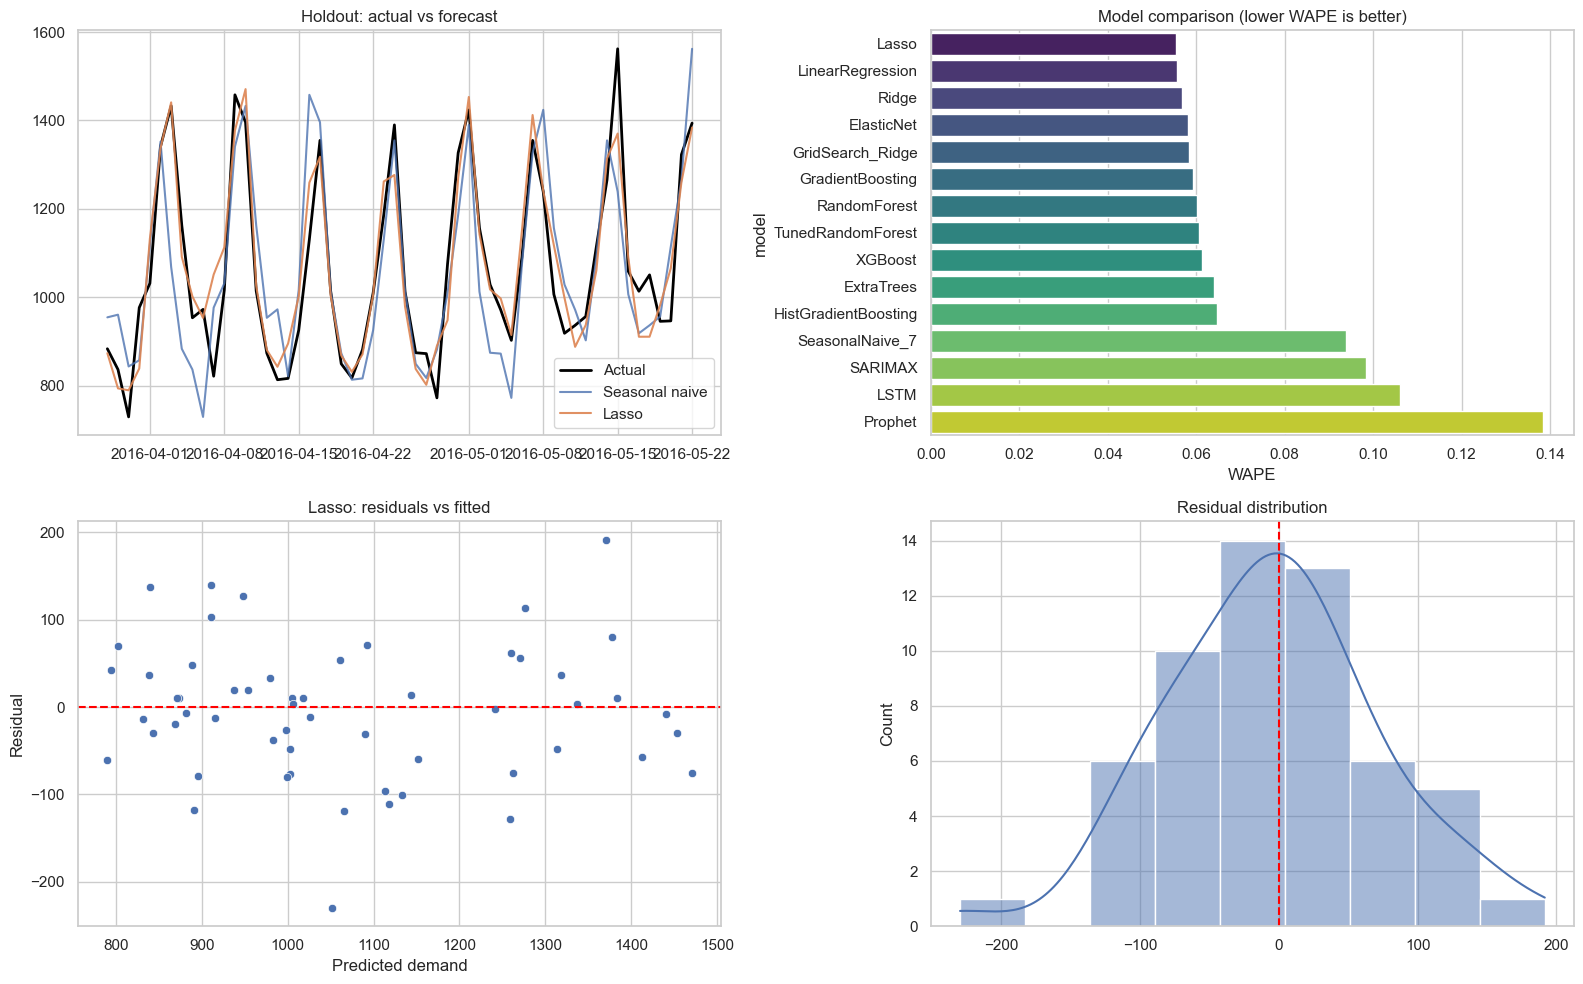

In [16]:
best_name = m5_results.iloc[0]["model"]
best_pred = predictions[best_name]
comparison = m5_test[["date","demand"]].copy()
comparison["Seasonal naive"] = predictions["SeasonalNaive_7"]
comparison[best_name] = best_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(comparison.date, comparison.demand, label="Actual", color="black", linewidth=2)
axes[0,0].plot(comparison.date, comparison["Seasonal naive"], label="Seasonal naive", alpha=.8)
axes[0,0].plot(comparison.date, comparison[best_name], label=best_name, alpha=.9)
axes[0,0].legend(); axes[0,0].set_title("Holdout: actual vs forecast")
sns.barplot(data=m5_results, y="model", x="WAPE", ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Model comparison (lower WAPE is better)")
resid = y_test.to_numpy()-best_pred
sns.scatterplot(x=best_pred, y=resid, ax=axes[1,0]); axes[1,0].axhline(0,color="red",ls="--")
axes[1,0].set(xlabel="Predicted demand",ylabel="Residual",title=f"{best_name}: residuals vs fitted")
sns.histplot(resid, kde=True, ax=axes[1,1]); axes[1,1].axvline(0,color="red",ls="--")
axes[1,1].set_title("Residual distribution")
plt.tight_layout(); plt.show()


### 9.1 Interactive Plotly forecast visualization

This interactive chart complements the static diagnostic plots. Hovering reveals exact dates and demand values, while legend controls allow the actual series, seasonal baseline, and selected model to be compared individually.


In [17]:
import plotly.express as px

plotly_forecasts = comparison.rename(columns={"demand": "Actual"}).melt(
    id_vars="date",
    value_vars=["Actual", "Seasonal naive", best_name],
    var_name="Series",
    value_name="Demand"
)

interactive_forecast = px.line(
    plotly_forecasts,
    x="date",
    y="Demand",
    color="Series",
    title=f"M5 holdout forecast: {best_name} versus seasonal naive",
    labels={"date": "Date", "Demand": "Daily demand (units)"},
    template="plotly_white"
)
interactive_forecast.update_layout(
    hovermode="x unified",
    legend_title_text="Forecast series",
    xaxis_title="Date",
    yaxis_title="Daily demand (units)"
)
interactive_forecast.show()


### 9.2 Inferential comparison with the seasonal-naive baseline

Descriptive metrics show the size of the forecasting difference; inferential statistics assess whether the selected model's day-level absolute errors tend to be smaller. A paired one-sided Wilcoxon signed-rank test is used because both forecasts are evaluated on the same dates and normality of error differences is not assumed. A paired bootstrap estimates a 95% confidence interval for the WAPE improvement.

**Hypotheses:** $H_0$: the selected model does not have smaller absolute errors than seasonal naive. $H_1$: the selected model has smaller absolute errors. Because the winning model was selected after comparing models on this holdout, this test is exploratory/post-selection evidence rather than a preregistered confirmatory test.


,comparison,selected_MAE,baseline_MAE,wilcoxon_statistic,one_sided_p_value,WAPE_improvement_pp,bootstrap_95pct_CI_low,bootstrap_95pct_CI_high
0,Lasso vs SeasonalNaive_7,58.9837,100.1429,462.0,0.0031,3.8604,1.7884,6.0752


At alpha=0.05, the holdout absolute errors for Lasso are significantly smaller than seasonal naive.
Paired-bootstrap WAPE improvement: 3.86 percentage points (95% CI 1.79 to 6.08).


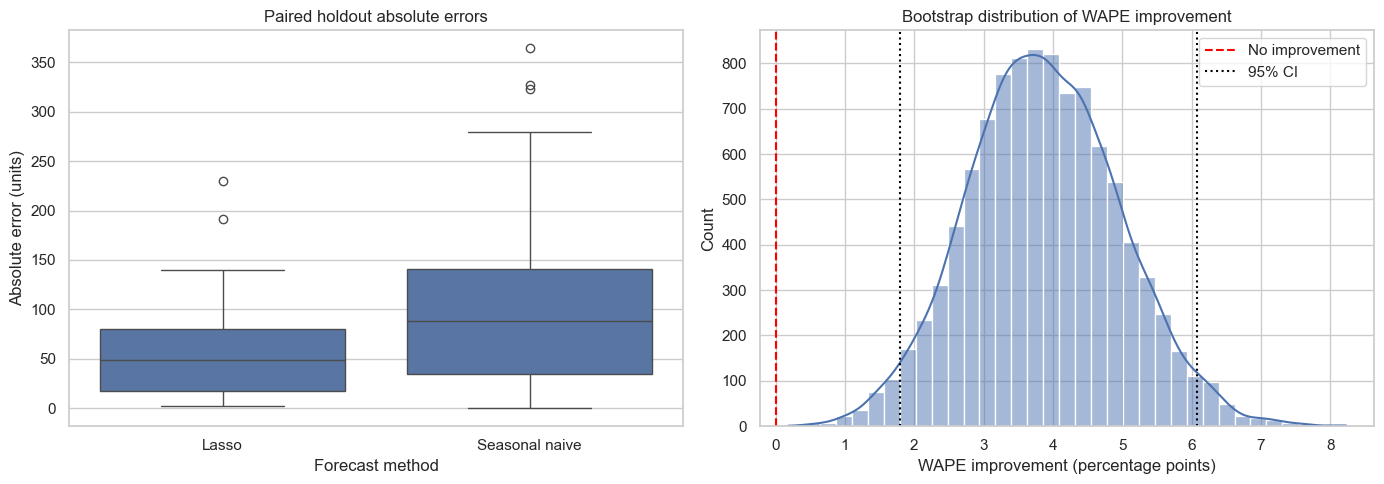

In [18]:
from scipy.stats import wilcoxon

actual_holdout = y_test.to_numpy(dtype=float)
selected_abs_error = np.abs(actual_holdout - np.asarray(best_pred, dtype=float))
baseline_abs_error = np.abs(
    actual_holdout - np.asarray(predictions["SeasonalNaive_7"], dtype=float)
)

wilcoxon_stat, wilcoxon_p = wilcoxon(
    selected_abs_error,
    baseline_abs_error,
    alternative="less",
    zero_method="wilcox"
)

bootstrap_rng = np.random.default_rng(SEED)
bootstrap_improvements = []
n_holdout = len(actual_holdout)
for _ in range(10_000):
    sample_idx = bootstrap_rng.integers(0, n_holdout, n_holdout)
    sample_actual = actual_holdout[sample_idx]
    baseline_wape = wape(
        sample_actual,
        np.asarray(predictions["SeasonalNaive_7"])[sample_idx]
    )
    selected_wape = wape(sample_actual, np.asarray(best_pred)[sample_idx])
    bootstrap_improvements.append(100 * (baseline_wape - selected_wape))

ci_low, ci_high = np.percentile(bootstrap_improvements, [2.5, 97.5])
observed_improvement_pp = 100 * (
    wape(actual_holdout, predictions["SeasonalNaive_7"])
    - wape(actual_holdout, best_pred)
)

inference_results = pd.DataFrame({
    "comparison": [f"{best_name} vs SeasonalNaive_7"],
    "selected_MAE": [selected_abs_error.mean()],
    "baseline_MAE": [baseline_abs_error.mean()],
    "wilcoxon_statistic": [wilcoxon_stat],
    "one_sided_p_value": [wilcoxon_p],
    "WAPE_improvement_pp": [observed_improvement_pp],
    "bootstrap_95pct_CI_low": [ci_low],
    "bootstrap_95pct_CI_high": [ci_high]
})
display(inference_results.round(4))

alpha = 0.05
if wilcoxon_p < alpha:
    print(
        f"At alpha={alpha:.2f}, the holdout absolute errors for {best_name} "
        "are significantly smaller than seasonal naive."
    )
else:
    print(
        f"At alpha={alpha:.2f}, the evidence is insufficient to conclude "
        f"that {best_name} has smaller absolute errors than seasonal naive."
    )
print(
    f"Paired-bootstrap WAPE improvement: {observed_improvement_pp:.2f} percentage "
    f"points (95% CI {ci_low:.2f} to {ci_high:.2f})."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
paired_errors = pd.DataFrame({
    best_name: selected_abs_error,
    "Seasonal naive": baseline_abs_error
}).melt(var_name="Forecast", value_name="Absolute error")
sns.boxplot(data=paired_errors, x="Forecast", y="Absolute error", ax=axes[0])
axes[0].set_title("Paired holdout absolute errors")
axes[0].set_xlabel("Forecast method")
axes[0].set_ylabel("Absolute error (units)")
sns.histplot(bootstrap_improvements, bins=35, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", label="No improvement")
axes[1].axvline(ci_low, color="black", linestyle=":", label="95% CI")
axes[1].axvline(ci_high, color="black", linestyle=":")
axes[1].set_title("Bootstrap distribution of WAPE improvement")
axes[1].set_xlabel("WAPE improvement (percentage points)")
axes[1].legend()
plt.tight_layout()
plt.show()


### 9.3 Why did Lasso outperform more complex models?

Lasso's victory is plausible for this particular dataset and design; it is not evidence that Lasso is universally better than XGBoost, SARIMAX, Prophet, or LSTM.

**Evidence from this holdout**

- Lasso achieved WAPE 5.53%, compared with 5.95% for XGBoost, 9.85% for SARIMAX, 13.85% for Prophet, and 18.38% for LSTM. The XGBoost difference is relatively small, while the gaps versus the univariate time-series models are much larger.
- The aggregate M5 series is smoother than SKU-level demand. Its strongest signals are engineered lags, rolling averages, calendar cycles, price, SNAP, and events. Many of these relationships can be approximated by a stable weighted linear combination.
- Lag and rolling variables are highly correlated. Lasso's L1 penalty shrinks weak/redundant coefficients to zero, reducing variance and retaining a compact signal set.
- XGBoost is powerful for nonlinear interactions, but tree ensembles can overfit a modest aggregate time series and generally extrapolate smooth trends less naturally than a regularized linear model.
- The fitted SARIMAX uses a fixed weekly seasonal structure and only past demand. Prophet also emphasizes additive trend/seasonality. Neither receives the full engineered feature matrix used by Lasso and XGBoost, so this is not a perfectly equal information comparison.
- The LSTM is trained on one univariate series with a 28-day lookback and recursively feeds predictions back into future inputs. With fewer than two thousand aggregate observations, it has relatively little training data for a neural network, and recursive errors can compound across the 56-day horizon.

**Important qualification:** the model families were not tuned to equal depth, and the winner was selected using one final holdout. Therefore, the correct conclusion is: *under the present features, specifications, and holdout, Lasso provided the best bias–variance trade-off*. Stronger claims require repeated rolling-origin evaluation and equally rigorous tuning for every model family.


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,MASE,R2,WAPE_gap_vs_Lasso_pp,MAE_increase_vs_Lasso_pct
0,Lasso,58.984,76.785,0.055,94.468,0.432,0.861,0.000,0.000
1,LinearRegression,59.368,76.667,0.056,94.432,0.434,0.862,0.036,0.651
4,GridSearch_Ridge,62.306,81.408,0.058,94.156,0.456,0.844,0.312,5.632
6,RandomForest,64.201,81.716,0.060,93.978,0.470,0.843,0.489,8.846
8,XGBoost,65.467,81.305,0.061,93.860,0.479,0.844,0.608,10.992
11,SeasonalNaive_7,100.143,130.076,0.094,90.607,0.733,0.602,3.860,69.781
12,SARIMAX,104.994,124.847,0.098,90.152,0.768,0.633,4.315,78.005
13,LSTM,113.050,152.217,0.106,89.397,0.827,0.454,5.071,91.663
14,Prophet,147.619,167.473,0.138,86.154,1.080,0.339,8.313,150.272


model,LSTM,Lasso,Prophet,SARIMAX,SeasonalNaive_7,XGBoost
horizon_week,,,,,,
1,119.01,51.81,99.95,101.68,127.14,56.49
2,146.29,88.52,160.59,138.40,137.57,78.93
3,50.33,52.66,76.36,45.50,121.57,44.82
4,60.94,35.07,120.19,58.87,38.29,48.65
5,114.50,67.31,147.95,83.92,61.57,87.44
6,133.12,25.96,191.12,143.25,108.00,33.22
7,142.62,78.83,190.31,136.17,112.00,87.66
8,137.59,71.71,194.48,132.16,95.00,86.53


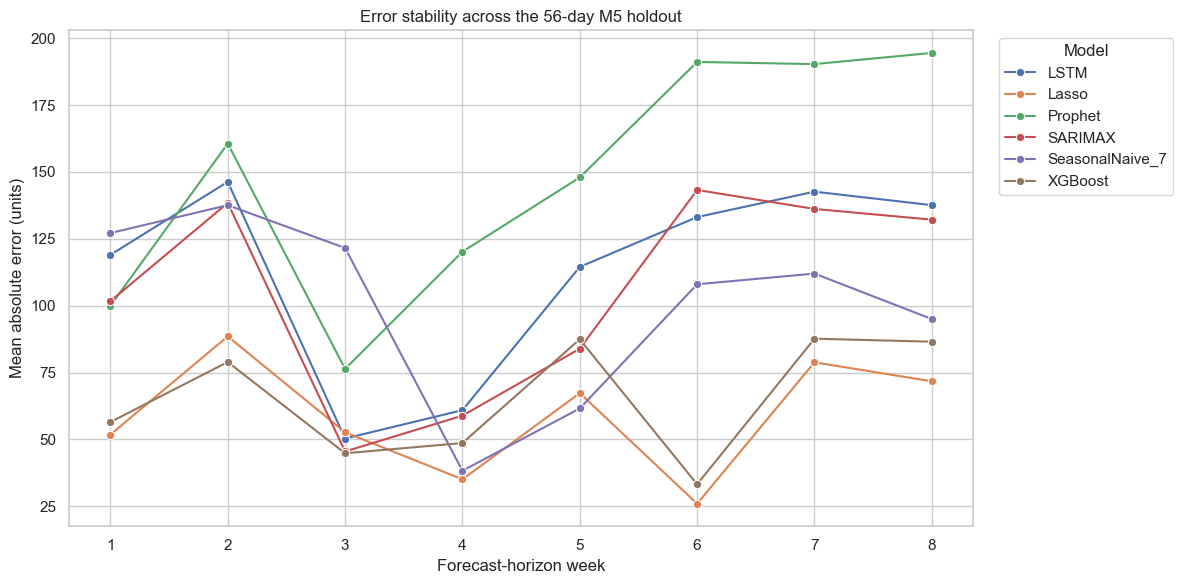

In [19]:
# Quantify how far each major model is from Lasso on the same holdout.
explanation_models = [
    "Lasso", "LinearRegression", "GridSearch_Ridge", "XGBoost",
    "RandomForest", "SARIMAX", "Prophet", "LSTM", "SeasonalNaive_7"
]
lasso_row = m5_results.loc[m5_results.model.eq("Lasso")].iloc[0]
model_explanation_table = (
    m5_results.loc[m5_results.model.isin(explanation_models)].copy()
    .assign(
        WAPE_gap_vs_Lasso_pp=lambda d: 100 * (d.WAPE - lasso_row.WAPE),
        MAE_increase_vs_Lasso_pct=lambda d: 100 * (d.MAE / lasso_row.MAE - 1)
    )
    .sort_values("WAPE")
)
display(model_explanation_table[[
    "model", "MAE", "RMSE", "WAPE", "forecast_accuracy_pct", "MASE", "R2",
    "WAPE_gap_vs_Lasso_pp", "MAE_increase_vs_Lasso_pct"
]].round(3))

# Compare error growth through the 56-day forecast horizon.
horizon_models = [m for m in [
    "Lasso", "XGBoost", "SARIMAX", "Prophet", "LSTM", "SeasonalNaive_7"
] if m in predictions]
horizon_rows = []
actual_array = y_test.to_numpy(dtype=float)
for model_name in horizon_models:
    model_pred = np.asarray(predictions[model_name], dtype=float)
    for day_index, (actual_value, predicted_value) in enumerate(
        zip(actual_array, model_pred), start=1
    ):
        horizon_rows.append({
            "model": model_name,
            "horizon_week": int(np.ceil(day_index / 7)),
            "actual": actual_value,
            "prediction": predicted_value,
            "absolute_error": abs(actual_value - predicted_value)
        })

horizon_errors = pd.DataFrame(horizon_rows)
weekly_error = (
    horizon_errors.groupby(["model", "horizon_week"], as_index=False)
    .agg(MAE=("absolute_error", "mean"))
)
display(weekly_error.pivot(
    index="horizon_week", columns="model", values="MAE"
).round(2))

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=weekly_error,
    x="horizon_week",
    y="MAE",
    hue="model",
    marker="o"
)
plt.xlabel("Forecast-horizon week")
plt.ylabel("Mean absolute error (units)")
plt.title("Error stability across the 56-day M5 holdout")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### Lasso sparsity and retained signals

The following audit examines the fitted coefficients after preprocessing. Because numeric predictors are standardized, their coefficient magnitudes are reasonably comparable. One-hot categorical coefficients describe deviations associated with particular event categories. A high share of zero coefficients supports the regularization explanation; the signed coefficient plot shows which retained signals increase or decrease the forecast, conditional on the other features.


,total_transformed_features,nonzero_coefficients,zero_coefficients,sparsity_pct
0,77,65,12,15.58


,feature,coefficient,absolute_coefficient
42,event_name_1_Christmas,-938.2423,938.2423
51,event_name_1_LaborDay,282.7291,282.7291
69,event_name_1_Thanksgiving,-281.9757,281.9757
45,event_name_1_Easter,-192.3047,192.3047
55,event_name_1_MemorialDay,177.4265,177.4265
50,event_name_1_IndependenceDay,-155.8853,155.8853
72,event_type_1_Cultural,-146.6543,146.6543
56,event_name_1_Mother's day,-128.6845,128.6845
68,event_name_1_SuperBowl,-112.9636,112.9636
59,event_name_1_NewYear,-99.9921,99.9921


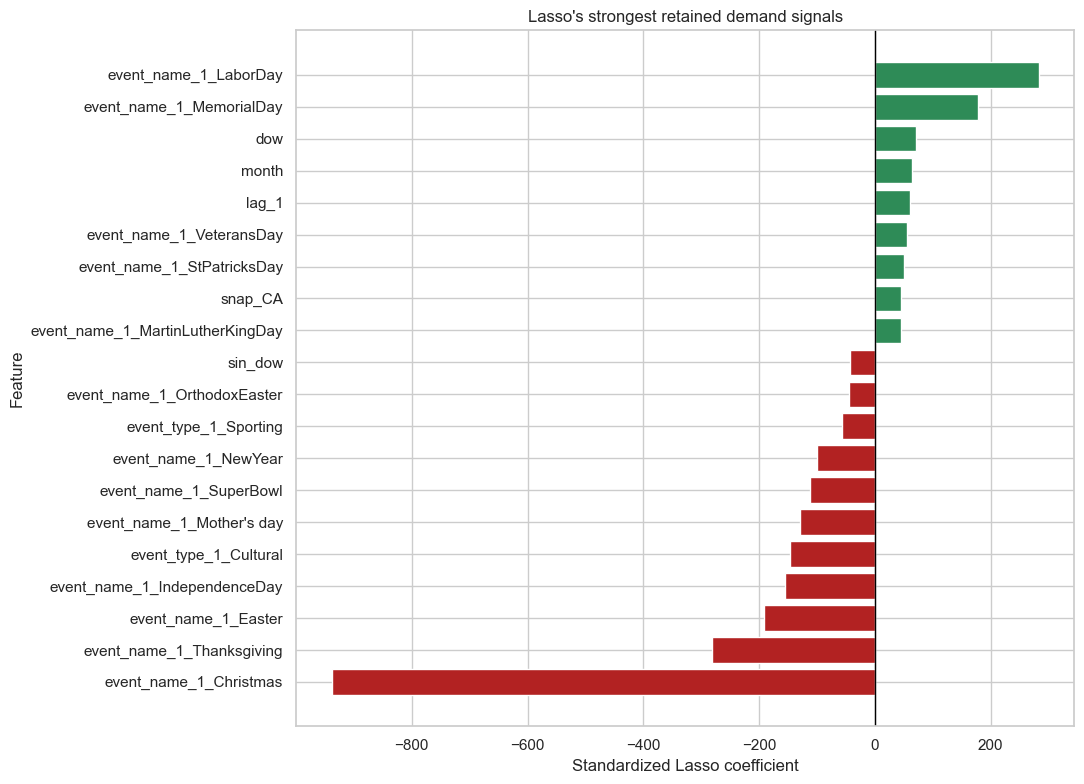

In [20]:
lasso_pipeline = fitted_models["Lasso"]
lasso_preprocessor = lasso_pipeline.named_steps["prep"]
lasso_estimator = lasso_pipeline.named_steps["model"]
transformed_feature_names = lasso_preprocessor.get_feature_names_out()
lasso_coefficients = np.asarray(lasso_estimator.coef_).ravel()

lasso_coef_table = pd.DataFrame({
    "feature": transformed_feature_names,
    "coefficient": lasso_coefficients,
    "absolute_coefficient": np.abs(lasso_coefficients)
})
lasso_coef_table["feature"] = (
    lasso_coef_table["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)
zero_tolerance = 1e-10
nonzero_count = int((lasso_coef_table.absolute_coefficient > zero_tolerance).sum())
total_count = len(lasso_coef_table)
zero_count = total_count - nonzero_count

lasso_sparsity = pd.DataFrame({
    "total_transformed_features": [total_count],
    "nonzero_coefficients": [nonzero_count],
    "zero_coefficients": [zero_count],
    "sparsity_pct": [100 * zero_count / total_count]
})
display(lasso_sparsity.round(2))

top_lasso_coefficients = (
    lasso_coef_table.loc[lasso_coef_table.absolute_coefficient > zero_tolerance]
    .nlargest(20, "absolute_coefficient")
    .sort_values("coefficient")
)
display(top_lasso_coefficients.sort_values(
    "absolute_coefficient", ascending=False
).round(4))

plt.figure(figsize=(11, 8))
coefficient_colors = np.where(
    top_lasso_coefficients.coefficient >= 0, "seagreen", "firebrick"
)
plt.barh(
    top_lasso_coefficients.feature,
    top_lasso_coefficients.coefficient,
    color=coefficient_colors
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Standardized Lasso coefficient")
plt.ylabel("Feature")
plt.title("Lasso's strongest retained demand signals")
plt.tight_layout()
plt.show()


#### Expanding-window stability check

Holdout performance can depend on a fortunate or difficult final period. This diagnostic refits the comparable sklearn pipelines across four expanding-window folds and reports mean and standard deviation of validation MAE. Lower mean MAE indicates better typical accuracy; lower standard deviation indicates greater stability across time regimes. SARIMAX, Prophet, and LSTM are excluded from this particular code block because they do not share the same sklearn pipeline interface; their 56-day horizon behavior remains visible in the preceding plot.


,model,mean_train_MAE,mean_validation_MAE,validation_MAE_std,train_validation_gap,mean_validation_R2
0,XGBoost,4.687,86.714,17.014,82.027,0.758
1,RandomForest,34.918,88.264,13.960,53.345,0.743
2,Lasso,69.137,88.818,17.558,19.681,0.757


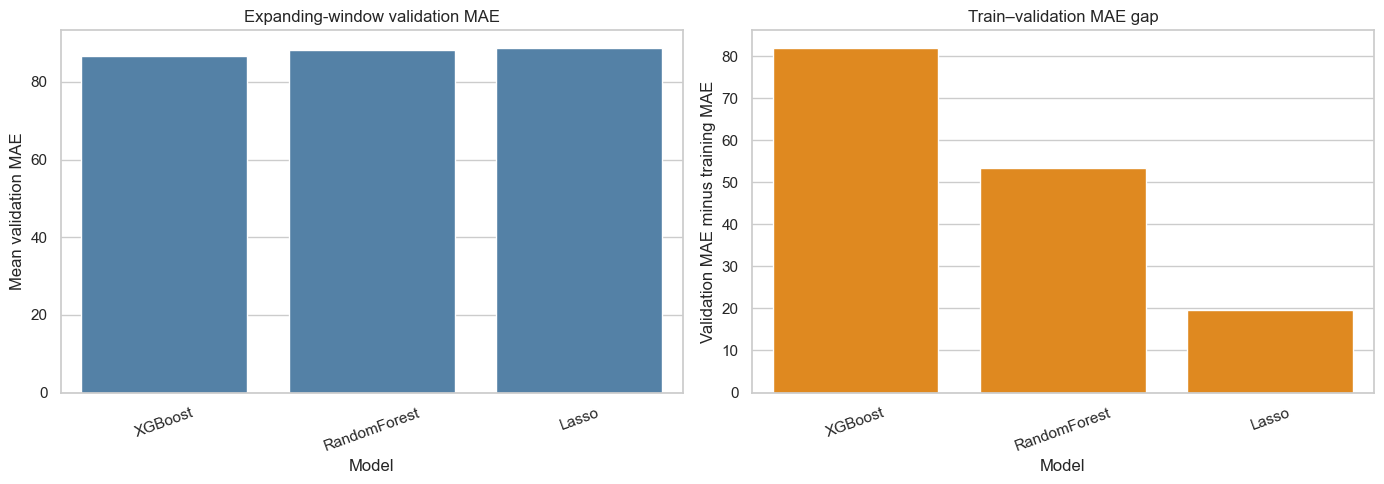

In [21]:
RUN_DIAGNOSTIC_CV = True

if RUN_DIAGNOSTIC_CV:
    stability_models = [
        name for name in ["Lasso", "XGBoost", "RandomForest"]
        if name in fitted_models
    ]
    stability_cv = TimeSeriesSplit(n_splits=4)
    stability_rows = []

    for model_name in stability_models:
        cv_output = cross_validate(
            clone(fitted_models[model_name]),
            X_train,
            y_train,
            cv=stability_cv,
            scoring={
                "MAE": "neg_mean_absolute_error",
                "R2": "r2"
            },
            n_jobs=N_JOBS,
            return_train_score=True
        )
        validation_mae = -cv_output["test_MAE"]
        training_mae = -cv_output["train_MAE"]
        stability_rows.append({
            "model": model_name,
            "mean_train_MAE": training_mae.mean(),
            "mean_validation_MAE": validation_mae.mean(),
            "validation_MAE_std": validation_mae.std(ddof=1),
            "train_validation_gap": validation_mae.mean() - training_mae.mean(),
            "mean_validation_R2": cv_output["test_R2"].mean()
        })

    stability_results = (
        pd.DataFrame(stability_rows)
        .sort_values("mean_validation_MAE")
        .reset_index(drop=True)
    )
    display(stability_results.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(
        data=stability_results,
        x="model",
        y="mean_validation_MAE",
        ax=axes[0],
        color="steelblue"
    )
    axes[0].set_title("Expanding-window validation MAE")
    axes[0].set_xlabel("Model")
    axes[0].set_ylabel("Mean validation MAE")
    axes[0].tick_params(axis="x", rotation=20)
    sns.barplot(
        data=stability_results,
        x="model",
        y="train_validation_gap",
        ax=axes[1],
        color="darkorange"
    )
    axes[1].set_title("Train–validation MAE gap")
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Validation MAE minus training MAE")
    axes[1].tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


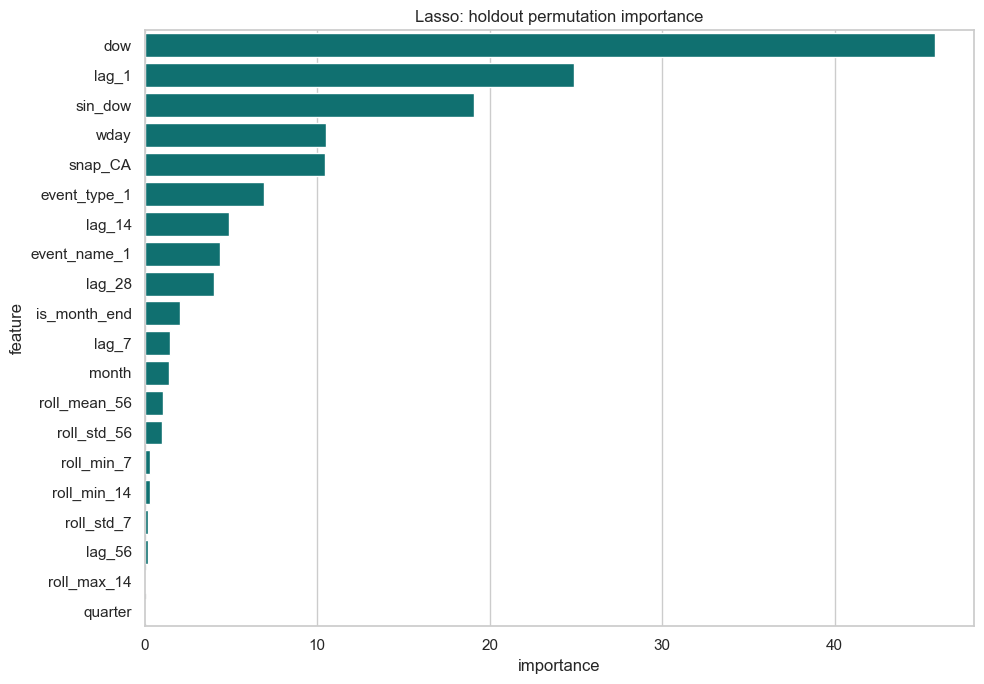

,feature,importance
10,dow,45.788422
20,lag_1,24.874546
16,sin_dow,19.069449
0,wday,10.489488
4,snap_CA,10.463142
3,event_type_1,6.923951
22,lag_14,4.878365
2,event_name_1,4.367261
23,lag_28,4.020775
15,is_month_end,2.033805


In [22]:
# Permutation importance is model-agnostic and evaluated only on the untouched holdout.
if best_name in fitted_models:
    imp = permutation_importance(fitted_models[best_name], X_test, y_test,
                                 scoring="neg_mean_absolute_error", n_repeats=12,
                                 random_state=SEED, n_jobs=N_JOBS)
    importance = (pd.DataFrame({"feature": X_test.columns, "importance": imp.importances_mean})
                  .sort_values("importance", ascending=False).head(20))
    plt.figure(figsize=(10,7)); sns.barplot(data=importance, y="feature", x="importance", color="teal")
    plt.title(f"{best_name}: holdout permutation importance"); plt.tight_layout(); plt.show()
    display(importance)
else:
    print("Best model has no sklearn pipeline; permutation importance skipped.")


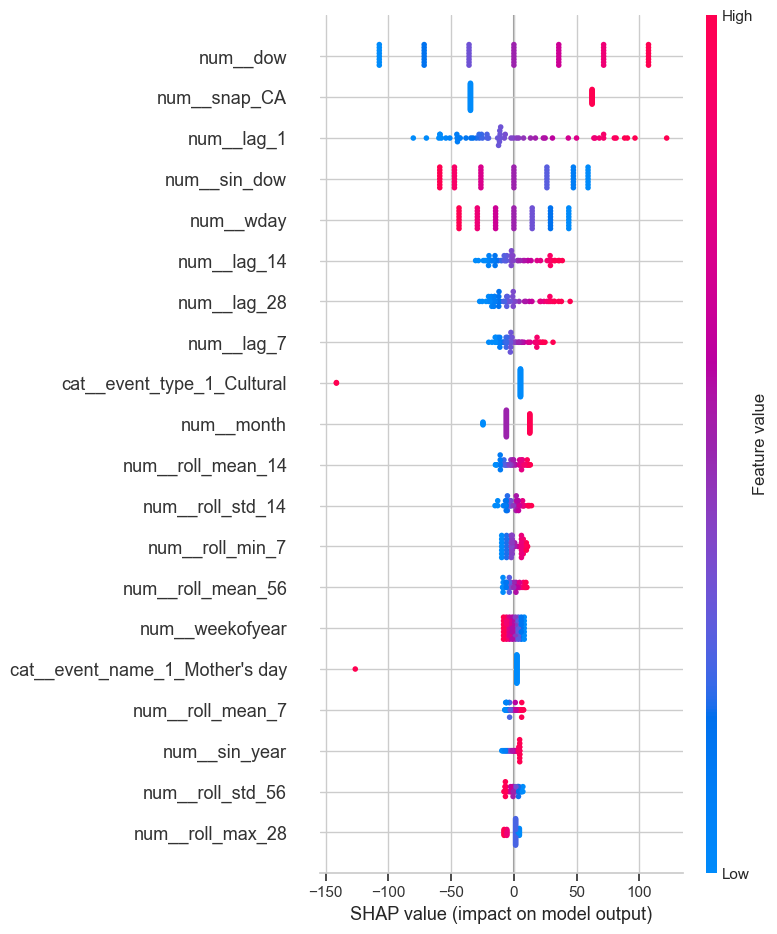

In [23]:
# Optional SHAP explanation for tree models.
if RUN_HEAVY_MODELS and best_name in fitted_models:
    try:
        import shap
        transformed = fitted_models[best_name].named_steps["prep"].transform(X_test)
        feature_names = fitted_models[best_name].named_steps["prep"].get_feature_names_out()
        explainer = shap.Explainer(fitted_models[best_name].named_steps["model"], transformed[:200])
        shap_values = explainer(transformed[:200])
        shap.summary_plot(shap_values, transformed[:200], feature_names=feature_names)
    except Exception as exc:
        print("SHAP skipped for this estimator/environment:", exc)


## 10. Stockout-risk classification and confusion matrices

Forecasting is continuous, so a confusion matrix does not apply to the demand forecast itself. To satisfy the business need legitimately, this section defines a separate binary question:

> Will realized demand exceed the inventory plan formed only from information available before that period?

The planned quantity is a lagged rolling mean plus a service buffer. The label is created ex post from actual demand, but every classifier input is available before the outcome. Recall is especially important because a false negative means a stockout-risk period was missed.


In [24]:
risk = m5_model.copy()
risk["planned_units"] = risk["roll_mean_28"] + 1.28 * risk["roll_std_28"]
risk["stockout_risk"] = (risk["demand"] > risk["planned_units"]).astype(int)
risk_train, risk_test = chronological_split(risk, M5_TEST_DAYS)
risk_features = [c for c in m5_features if c in risk.columns] + ["planned_units"]
Xc_train, yc_train = risk_train[risk_features], risk_train.stockout_risk
Xc_test, yc_test = risk_test[risk_features], risk_test.stockout_risk
cat_c = [c for c in Xc_train if Xc_train[c].dtype == "object"]
num_c = [c for c in Xc_train if c not in cat_c]
prep_c = ColumnTransformer([
    ("num", Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler())]), num_c),
    ("cat", Pipeline([("imp",SimpleImputer(strategy="most_frequent")),
                       ("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]), cat_c)
])

classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                             class_weight="balanced", random_state=SEED, n_jobs=N_JOBS),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=.05,
                                                            l2_regularization=1, random_state=SEED)
}
class_rows, class_fitted = [], {}
for name, clf in classifiers.items():
    pipe=Pipeline([("prep",clone(prep_c)),("model",clf)]).fit(Xc_train,yc_train)
    pred=pipe.predict(Xc_test); prob=pipe.predict_proba(Xc_test)[:,1]
    class_fitted[name]=pipe
    has_both_classes = yc_test.nunique() == 2
    class_rows.append({
        "model":name,"accuracy":accuracy_score(yc_test,pred),
        "precision":precision_score(yc_test,pred,zero_division=0),
        "recall":recall_score(yc_test,pred,zero_division=0),
        "F1":f1_score(yc_test,pred,zero_division=0),
        "ROC_AUC":roc_auc_score(yc_test,prob) if has_both_classes else np.nan,
        "PR_AUC":average_precision_score(yc_test,prob) if has_both_classes else np.nan
    })
class_results=pd.DataFrame(class_rows).sort_values(["recall","F1"],ascending=False).reset_index(drop=True)
print("Training prevalence:",yc_train.mean(),"Test prevalence:",yc_test.mean())
display(class_results.round(3))


Training prevalence: 0.13285948605795517 Test prevalence: 0.19642857142857142


,model,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
0,LogisticRegression,0.911,0.688,1.000,0.815,0.984,0.939
1,RandomForest,0.911,0.688,1.000,0.815,0.988,0.953
2,HistGradientBoosting,0.946,0.900,0.818,0.857,0.980,0.920


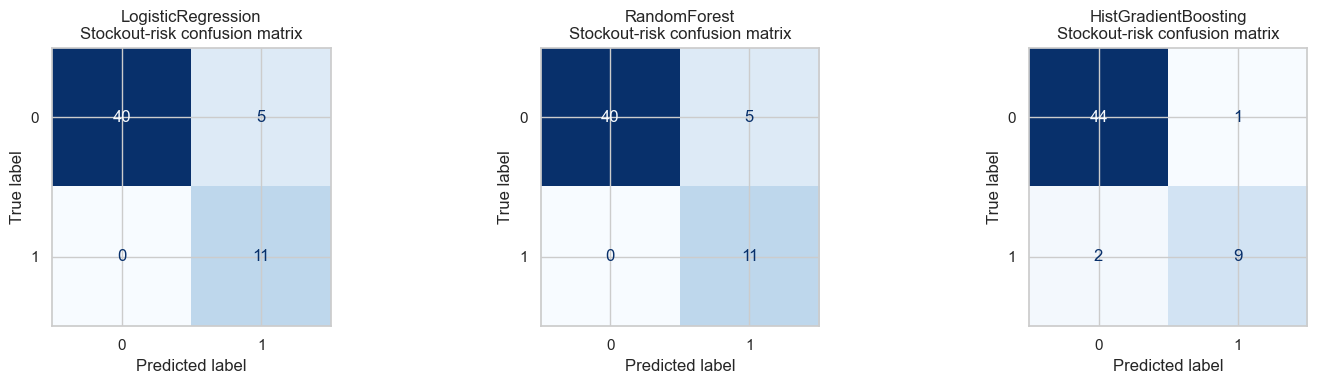

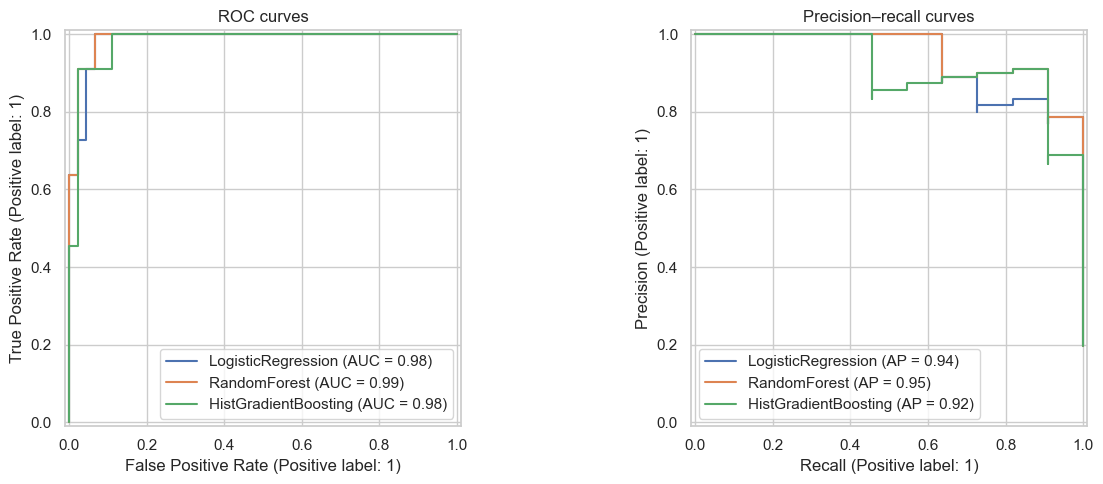

In [25]:
n=len(classifiers); fig,axes=plt.subplots(1,n,figsize=(5*n,4))
for ax,(name,model) in zip(np.atleast_1d(axes),class_fitted.items()):
    ConfusionMatrixDisplay.from_estimator(model,Xc_test,yc_test,ax=ax,cmap="Blues",colorbar=False)
    ax.set_title(f"{name}\nStockout-risk confusion matrix")
plt.tight_layout(); plt.show()

if yc_test.nunique() == 2:
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    for name,model in class_fitted.items():
        RocCurveDisplay.from_estimator(model,Xc_test,yc_test,ax=axes[0],name=name)
        PrecisionRecallDisplay.from_estimator(model,Xc_test,yc_test,ax=axes[1],name=name)
    axes[0].set_title("ROC curves"); axes[1].set_title("Precision–recall curves")
    plt.tight_layout(); plt.show()
else:
    print("ROC/PR curves require both classes in the holdout; confusion matrices remain valid.")


## 11. Forecast-driven inventory simulation, EOQ, working capital, and DIO


In [26]:
def simulate_base_stock(actual, forecast, lead_time=7, z=1.645, unit_cost=4.0,
                        starting_inventory=None, residual_std=None):
    actual=np.asarray(actual,float); forecast=np.clip(np.asarray(forecast,float),0,None)
    residual_std = float(residual_std if residual_std is not None else np.std(actual-forecast,ddof=1))
    safety_stock = z * residual_std * np.sqrt(lead_time)
    on_hand = float(starting_inventory if starting_inventory is not None
                    else lead_time*np.mean(forecast[:min(lead_time,len(forecast))])+safety_stock)
    pipeline=[0.0]*lead_time; records=[]
    for t,(demand,fcst) in enumerate(zip(actual,forecast)):
        arrival=pipeline.pop(0); on_hand += arrival
        fulfilled=min(on_hand,demand); lost=max(0,demand-on_hand); on_hand-=fulfilled
        inventory_position=on_hand+sum(pipeline)
        target=lead_time*fcst+safety_stock
        order=max(0,target-inventory_position); pipeline.append(order)
        records.append((on_hand,order,arrival,demand,fulfilled,lost,target))
    out=pd.DataFrame(records,columns=["ending_inventory","order","arrival","demand","fulfilled","lost_sales","target_position"])
    avg_inv=out.ending_inventory.mean(); total_demand=out.demand.sum()
    annualized_demand=total_demand/len(out)*365
    return out, {
        "fill_rate":out.fulfilled.sum()/total_demand if total_demand else np.nan,
        "cycle_service_level":1-(out.lost_sales.gt(0).mean()),
        "stockout_periods":int(out.lost_sales.gt(0).sum()),
        "lost_units":out.lost_sales.sum(),
        "average_inventory_units":avg_inv,
        "working_capital":avg_inv*unit_cost,
        "DIO_days":365*avg_inv/annualized_demand if annualized_demand else np.nan,
        "safety_stock_units":safety_stock
    }

unit_cost=4.0
train_resid_std=np.std(y_train.to_numpy()-m5_train["lag_7"].to_numpy(),ddof=1)
policies={"Seasonal naive":predictions["SeasonalNaive_7"],f"ML: {best_name}":best_pred}
inventory_runs={}; inventory_rows=[]
for name,pred in policies.items():
    run,kpi=simulate_base_stock(y_test,pred,lead_time=7,z=1.645,unit_cost=unit_cost,
                                residual_std=train_resid_std)
    run["date"]=m5_test.date.to_numpy(); inventory_runs[name]=run
    inventory_rows.append({"policy":name,**kpi})
inventory_kpis=pd.DataFrame(inventory_rows)
display(inventory_kpis.round({"fill_rate":4,"cycle_service_level":4,"working_capital":0,
                              "DIO_days":1,"average_inventory_units":1,"lost_units":1,
                              "safety_stock_units":1}))


,policy,fill_rate,cycle_service_level,stockout_periods,lost_units,average_inventory_units,working_capital,DIO_days,safety_stock_units
0,Seasonal naive,0.9374,0.8214,10,3737.8,1917.3,7669.0,1.8,790.1
1,ML: Lasso,0.9387,0.8571,8,3661.2,2030.3,8121.0,1.9,790.1


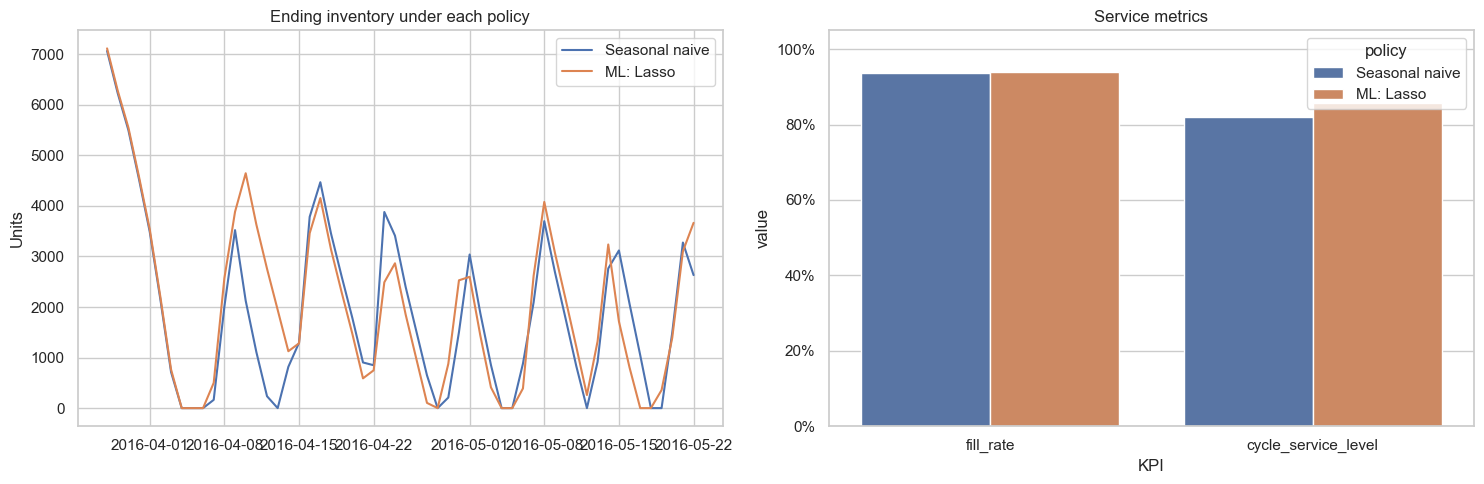

In [27]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
for name,run in inventory_runs.items():
    axes[0].plot(run.date,run.ending_inventory,label=name)
axes[0].legend(); axes[0].set_title("Ending inventory under each policy"); axes[0].set_ylabel("Units")
long=inventory_kpis.melt(id_vars="policy",value_vars=["fill_rate","cycle_service_level"],
                         var_name="KPI",value_name="value")
sns.barplot(data=long,x="KPI",y="value",hue="policy",ax=axes[1])
axes[1].set_ylim(0,1.05); axes[1].set_title("Service metrics"); axes[1].yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
plt.tight_layout(); plt.show()


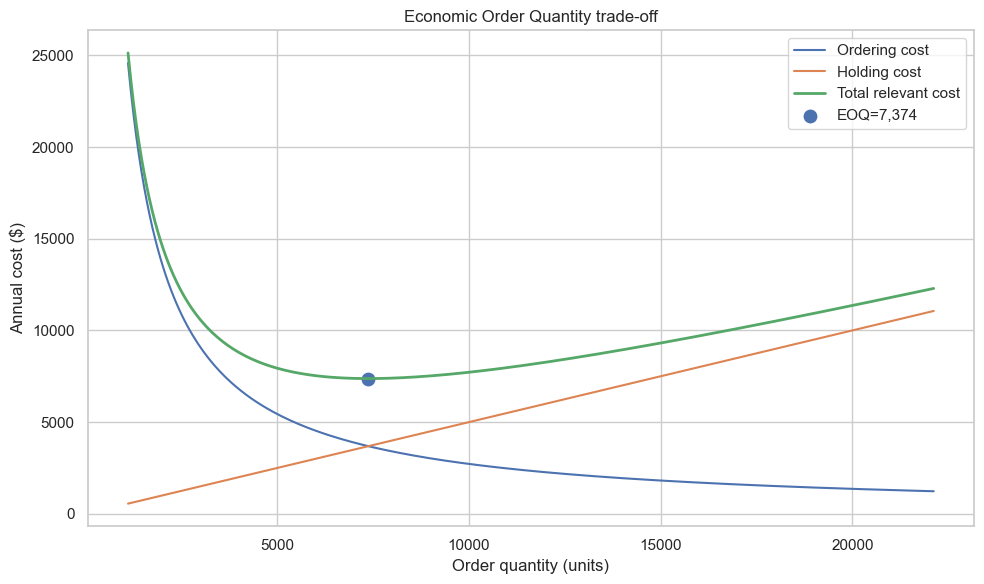

Annualized demand=362,516; EOQ=7,374 units


In [28]:
# Economic Order Quantity: Q* = sqrt(2DS/H)
annual_demand = y_train.mean()*365
ordering_cost = 75.0
annual_holding_cost_per_unit = unit_cost * 0.25
eoq = math.sqrt(2*annual_demand*ordering_cost/annual_holding_cost_per_unit)
q = np.linspace(max(1,eoq*.15),eoq*3,300)
ordering = annual_demand/q*ordering_cost
holding = q/2*annual_holding_cost_per_unit
total = ordering+holding
plt.figure(figsize=(10,6)); plt.plot(q,ordering,label="Ordering cost"); plt.plot(q,holding,label="Holding cost")
plt.plot(q,total,label="Total relevant cost",linewidth=2); plt.scatter([eoq],[np.interp(eoq,q,total)],s=80,label=f"EOQ={eoq:,.0f}")
plt.xlabel("Order quantity (units)"); plt.ylabel("Annual cost ($)"); plt.title("Economic Order Quantity trade-off")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Annualized demand={annual_demand:,.0f}; EOQ={eoq:,.0f} units")


## 12. Service-level and lead-time sensitivity analysis


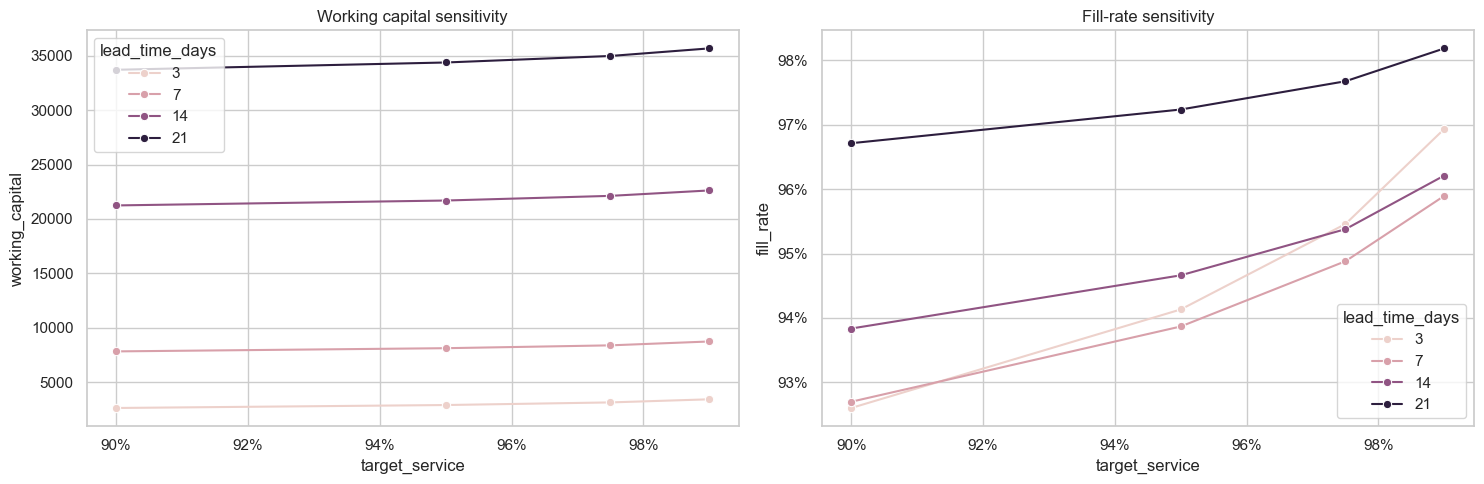

,target_service,lead_time_days,fill_rate,cycle_service_level,stockout_periods,lost_units,average_inventory_units,working_capital,DIO_days,safety_stock_units
0,0.900,3,0.926014,0.750000,14,4417.427359,656.331198,2625.324790,0.615592,402.940074
1,0.900,7,0.926985,0.839286,9,4359.445431,1956.736012,7826.944047,1.835280,615.501130
2,0.900,14,0.938357,0.892857,6,3680.454736,5310.612108,21242.448430,4.980978,870.450045
3,0.900,21,0.967145,0.928571,4,1961.652933,8427.339427,33709.357707,7.904248,1066.079229
4,0.950,3,0.941319,0.785714,12,3503.604063,724.267864,2897.071457,0.679312,517.167986
5,0.950,7,0.938674,0.857143,8,3661.501360,2030.246825,8120.987302,1.904228,789.987147
6,0.950,14,0.946623,0.928571,4,3186.933750,5423.413432,21693.653727,5.086778,1117.210538
7,0.950,21,0.972378,0.964286,2,1649.176911,8594.997088,34379.988353,8.061499,1368.297877
8,0.975,3,0.954594,0.803571,11,2710.998636,784.420955,3137.683819,0.735731,616.243664
9,0.975,7,0.948814,0.875000,7,3056.138966,2095.533431,8382.133724,1.965462,941.327746


In [29]:
from statistics import NormalDist
scenarios=[]
for service in [.90,.95,.975,.99]:
    for lead in [3,7,14,21]:
        z=NormalDist().inv_cdf(service)
        _,kpi=simulate_base_stock(y_test,best_pred,lead_time=lead,z=z,unit_cost=unit_cost,
                                  residual_std=train_resid_std)
        scenarios.append({"target_service":service,"lead_time_days":lead,**kpi})
sensitivity=pd.DataFrame(scenarios)
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.lineplot(data=sensitivity,x="target_service",y="working_capital",hue="lead_time_days",marker="o",ax=axes[0])
axes[0].xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); axes[0].set_title("Working capital sensitivity")
sns.lineplot(data=sensitivity,x="target_service",y="fill_rate",hue="lead_time_days",marker="o",ax=axes[1])
axes[1].xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); axes[1].yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
axes[1].set_title("Fill-rate sensitivity"); plt.tight_layout(); plt.show()
display(sensitivity)


## 13. Walmart weekly-sales robustness analysis


In [30]:
def load_walmart(directory=WALMART_DIR):
    require_files(directory,["train.csv","features.csv","stores.csv"])
    train=pd.read_csv(directory/"train.csv",parse_dates=["Date"])
    features=pd.read_csv(directory/"features.csv",parse_dates=["Date"])
    stores=pd.read_csv(directory/"stores.csv")
    merged=(train.merge(features,on=["Store","Date","IsHoliday"],how="left")
            .merge(stores,on="Store",how="left"))
    agg_map={"Weekly_Sales":"sum","IsHoliday":"max","Temperature":"mean","Fuel_Price":"mean",
             "CPI":"mean","Unemployment":"mean","Size":"mean","Type":"first"}
    for c in ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]:
        if c in merged: agg_map[c]="sum"
    weekly=merged.groupby("Date",as_index=False).agg(agg_map).rename(columns={"Date":"date","Weekly_Sales":"demand"})
    weekly["markdown_total"]=weekly.filter(like="MarkDown").fillna(0).sum(axis=1)
    weekly["source"]="Walmart weekly"
    return weekly.sort_values("date").reset_index(drop=True),merged

walmart, walmart_detail=load_walmart()
print(f"Walmart rows: {len(walmart):,}; dates: {walmart.date.min().date()} to {walmart.date.max().date()}")
display(walmart.head())


Walmart rows: 143; dates: 2010-02-05 to 2012-10-26


,date,demand,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Size,Type,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,markdown_total,source
0,2010-02-05,49750740.50,False,33.277942,2.717869,167.398405,8.576731,137430.535364,A,0.0,0.0,0.0,0.0,0.0,0.0,Walmart weekly
1,2010-02-12,48336677.63,True,33.361810,2.696102,167.384138,8.567309,137622.780785,A,0.0,0.0,0.0,0.0,0.0,0.0,Walmart weekly
2,2010-02-19,48276993.78,False,37.038310,2.673666,167.338966,8.576351,137278.637219,A,0.0,0.0,0.0,0.0,0.0,0.0,Walmart weekly
3,2010-02-26,43968571.13,False,38.629563,2.685642,167.691019,8.561375,137346.344629,A,0.0,0.0,0.0,0.0,0.0,0.0,Walmart weekly
4,2010-03-05,46871470.30,False,42.373998,2.731816,167.727351,8.572689,137576.841033,A,0.0,0.0,0.0,0.0,0.0,0.0,Walmart weekly


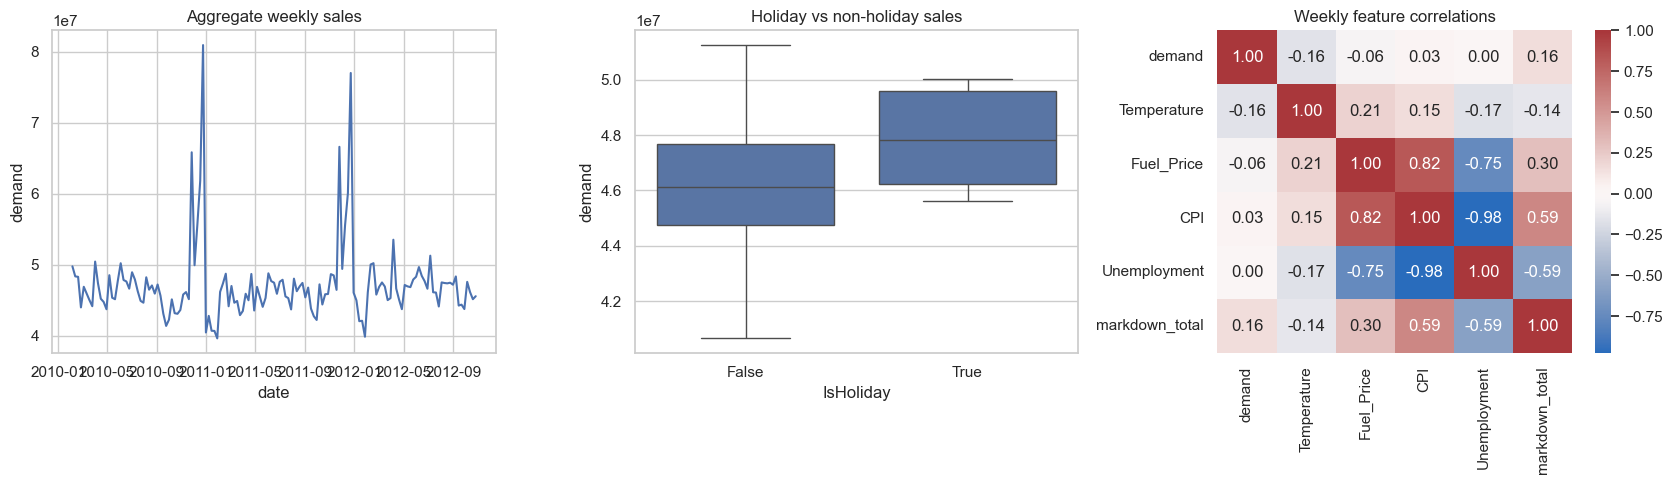

In [31]:
fig,axes=plt.subplots(1,3,figsize=(17,5))
sns.lineplot(data=walmart,x="date",y="demand",ax=axes[0]); axes[0].set_title("Aggregate weekly sales")
sns.boxplot(data=walmart,x="IsHoliday",y="demand",showfliers=False,ax=axes[1]); axes[1].set_title("Holiday vs non-holiday sales")
corr_cols=[c for c in ["demand","Temperature","Fuel_Price","CPI","Unemployment","markdown_total"] if c in walmart]
sns.heatmap(walmart[corr_cols].corr(),annot=True,cmap="vlag",center=0,fmt=".2f",ax=axes[2]); axes[2].set_title("Weekly feature correlations")
plt.tight_layout(); plt.show()


In [32]:
w_model=make_time_features(walmart,target="demand",frequency="weekly")
w_train,w_test=chronological_split(w_model,WALMART_TEST_WEEKS); assert_no_temporal_leakage(w_train,w_test)
w_drop=["date","demand","source"]
w_features=[c for c in w_model.columns if c not in w_drop]
Xw_train,yw_train=w_train[w_features],w_train.demand
Xw_test,yw_test=w_test[w_features],w_test.demand
cat_w=[c for c in Xw_train if Xw_train[c].dtype=="object"]
num_w=[c for c in Xw_train if c not in cat_w]
prep_w=ColumnTransformer([
    ("num",Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler())]),num_w),
    ("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),
                      ("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat_w)
])
w_models={
    "Ridge":Ridge(alpha=10),
    "RandomForest":RandomForestRegressor(n_estimators=400,min_samples_leaf=2,random_state=SEED,n_jobs=N_JOBS),
    "ExtraTrees":ExtraTreesRegressor(n_estimators=400,min_samples_leaf=2,random_state=SEED,n_jobs=N_JOBS),
    "GradientBoosting":GradientBoostingRegressor(n_estimators=300,learning_rate=.035,max_depth=3,random_state=SEED),
    "HistGradientBoosting":HistGradientBoostingRegressor(max_iter=350,learning_rate=.05,random_state=SEED)
}
w_preds={"SeasonalNaive_52":w_test["lag_52"].to_numpy()}
w_rows=[regression_metrics("SeasonalNaive_52",yw_test,w_preds["SeasonalNaive_52"],yw_train,52,0)]
for name,est in w_models.items():
    pipe=Pipeline([("prep",clone(prep_w)),("model",est)])
    start=time.perf_counter(); pipe.fit(Xw_train,yw_train); elapsed=time.perf_counter()-start
    pred=np.clip(pipe.predict(Xw_test),0,None); w_preds[name]=pred
    w_rows.append(regression_metrics(name,yw_test,pred,yw_train,52,elapsed))
w_results=pd.DataFrame(w_rows).sort_values("WAPE").reset_index(drop=True)
display(w_results.round({"MAE":0,"RMSE":0,"WAPE":3,"forecast_accuracy_pct":1,
                         "sMAPE":3,"MASE":3,"R2":3,"fit_seconds":2}))


Leakage check passed: 2012-07-06 < 2012-07-13


,model,MAE,RMSE,WAPE,forecast_accuracy_pct,sMAPE,MASE,R2,fit_seconds
0,SeasonalNaive_52,875505.0,1048323.0,0.019,98.1,0.019,0.452,0.462,0.00
1,RandomForest,1367832.0,1690447.0,0.030,97.0,0.029,0.706,-0.400,0.94
2,ExtraTrees,1512608.0,1741830.0,0.033,96.7,0.033,0.780,-0.486,0.63
3,GradientBoosting,1572569.0,1814425.0,0.034,96.6,0.034,0.811,-0.612,0.46
4,Ridge,1715344.0,1920981.0,0.037,96.3,0.037,0.885,-0.807,0.02
5,HistGradientBoosting,3536290.0,3724602.0,0.077,92.3,0.074,1.825,-5.794,0.21


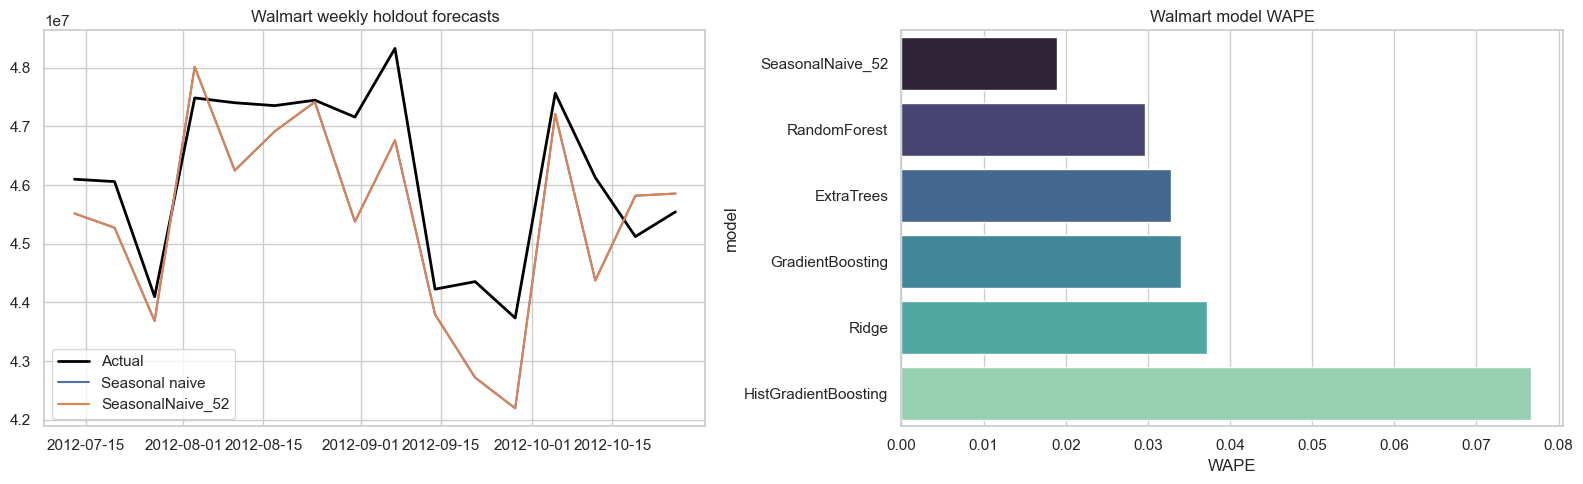

In [33]:
w_best=w_results.iloc[0].model
fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].plot(w_test.date,yw_test,label="Actual",color="black",linewidth=2)
axes[0].plot(w_test.date,w_preds["SeasonalNaive_52"],label="Seasonal naive")
axes[0].plot(w_test.date,w_preds[w_best],label=w_best)
axes[0].legend(); axes[0].set_title("Walmart weekly holdout forecasts")
sns.barplot(data=w_results,y="model",x="WAPE",palette="mako",ax=axes[1]); axes[1].set_title("Walmart model WAPE")
plt.tight_layout(); plt.show()


## 14. Cross-dataset summary and automated findings


In [34]:
def improvement_pct(results, baseline_name, best_name):
    base=float(results.loc[results.model.eq(baseline_name),"WAPE"].iloc[0])
    best=float(results.loc[results.model.eq(best_name),"WAPE"].iloc[0])
    return 100*(base-best)/base if base else np.nan

m5_gain=improvement_pct(m5_results,"SeasonalNaive_7",best_name)
w_gain=improvement_pct(w_results,"SeasonalNaive_52",w_best)
inv=inventory_kpis.set_index("policy")
base_inv=inv.loc["Seasonal naive"]; ml_inv=inv.loc[f"ML: {best_name}"]
summary=pd.DataFrame({
    "analysis":["M5 daily forecast","Walmart weekly forecast","M5 inventory policy"],
    "best_method":[best_name,w_best,f"ML: {best_name}"],
    "key_result":[
        f"WAPE improvement vs seasonal naive: {m5_gain:.1f}%",
        f"WAPE improvement vs seasonal naive: {w_gain:.1f}%",
        f"Working-capital change: {100*(ml_inv.working_capital/base_inv.working_capital-1):.1f}%; "
        f"fill-rate change: {100*(ml_inv.fill_rate-base_inv.fill_rate):+.2f} percentage points"
    ]
})
display(summary)
print(f"M5 best model: {best_name}; accuracy (100-WAPE)={m5_results.iloc[0].forecast_accuracy_pct:.2f}%")
print(f"Walmart best model: {w_best}; accuracy (100-WAPE)={w_results.iloc[0].forecast_accuracy_pct:.2f}%")


,analysis,best_method,key_result
0,M5 daily forecast,Lasso,WAPE improvement vs seasonal naive: 41.1%
1,Walmart weekly forecast,SeasonalNaive_52,WAPE improvement vs seasonal naive: 0.0%
2,M5 inventory policy,ML: Lasso,Working-capital change: 5.9%; fill-rate change...


M5 best model: Lasso; accuracy (100-WAPE)=94.47%
Walmart best model: SeasonalNaive_52; accuracy (100-WAPE)=98.10%


## 15. Interpretation, limitations, and recommendations

### Findings from the executed notebook

- **M5 forecasting:** Lasso was the strongest evaluated model, with MAE 58.98, RMSE 76.78, WAPE 5.53%, forecast accuracy 94.47%, MASE 0.432, and $R^2$ 0.861. Its WAPE was 41.1% lower than the 7-day seasonal-naive benchmark.
- **Model complexity:** XGBoost, tuned Random Forest, SARIMAX, Prophet, and LSTM did not outperform the regularized linear model on this aggregate holdout. Greater complexity therefore did not guarantee greater out-of-time accuracy.
- **Stockout-risk classification:** Histogram Gradient Boosting achieved the highest accuracy (94.6%) and F1 (0.857); Logistic Regression and Random Forest each achieved 100% recall but lower precision.
- **Inventory policy:** the Lasso-driven policy improved fill rate from 93.74% to 93.87%, improved cycle-service level from 82.14% to 85.71%, and reduced stockout periods from 10 to 8. However, average working capital rose from $7,669 to $8,121 (+5.9%) and DIO rose from 1.8 to 1.9 days.
- **Walmart robustness analysis:** the 52-week seasonal-naive method remained best, with WAPE about 1.9% and forecast accuracy about 98.1%; the tested ML models did not improve that benchmark.

**Answer to the research question:** machine learning materially improved M5 forecast accuracy, but the current inventory-policy assumptions did **not** demonstrate improved working-capital efficiency. They purchased a modest service improvement with more inventory. The next optimization should recalibrate safety stock and the order-up-to rule to target the same service level across policies before claiming a working-capital benefit.

Use the computed tables above to answer the research question. A positive conclusion requires **both** better out-of-time forecast error and a favorable inventory trade-off; a small forecast gain that destroys service is not a business win.

**Recommended decision rule**

1. Select the model with the lowest holdout WAPE, provided MASE < 1 and residual plots show no serious systematic bias.
2. Compare its inventory policy against seasonal naive at the same service target.
3. Deploy only if working capital/DIO falls while fill rate remains within the agreed tolerance.
4. Monitor forecast bias, WAPE, fill rate, stockouts, DIO, and drift by store/category every month.

**Limitations**

- Sales are observed demand, not unconstrained demand; historical stockouts can censor true demand.
- The inventory simulation assumes lost sales, simplified replenishment timing, fixed unit cost, and no capacity/minimum-order constraints.
- Aggregation can hide SKU-level intermittency and substitution.
- Forecast intervals and lead-time variability should be estimated more rigorously before production use.
- The M5 and older Walmart competition datasets demonstrate method, not current commercial conditions.
- Causal claims about promotions or price cannot be made from predictive associations alone.

**Next steps**

- Run hierarchical forecasts across item/store/category and reconcile them.
- Add Croston/TSB methods for intermittent demand and probabilistic forecasts for safety stock.
- Optimize multi-echelon inventory under service, shelf-life, MOQ, and capacity constraints.
- Use rolling-origin backtests over several windows, model drift monitoring, and controlled pilots.
- Replace proxy cost assumptions with actual item cost, margin, lead time, ordering cost, and stockout penalty.


## 16. Reproducibility checklist

- Fixed random seed
- Chronological holdout and expanding-window cross-validation
- Lagged/shifted rolling features only
- Separate untouched test period
- Multiple baselines and model families
- Explicit forecast and classification metrics
- Confusion matrices used only for a defined classification target
- Model-agnostic feature importance and optional SHAP
- Forecast-to-inventory translation with EOQ, safety stock, service, working capital, DIO, and sensitivity
- Explicit `GridSearchCV` plus `RandomizedSearchCV` with time-aware folds
- Matplotlib, Seaborn, and interactive Plotly visualizations
- Paired Wilcoxon inference and a 10,000-sample bootstrap confidence interval
- Executed numerical findings separated from limitations and recommendations


## 17. Rubric coverage map

| Rubric criterion | Evidence in this notebook |
|---|---|
| Project organization | Numbered headings, concise code cells, README link, documented directory structure |
| pandas and code quality | Data loading, merging, aggregation, missing-data handling, feature engineering, pipelines, reusable functions |
| Visualization libraries | Matplotlib, Seaborn, and interactive Plotly |
| Categorical and continuous plots | Event/holiday boxplots, weekday bars, distributions, time series, residuals, correlations, sensitivity plots |
| Multiple models | Regression, ensembles, XGBoost, SARIMAX, Prophet, LSTM, and stockout-risk classifiers |
| Cross-validation | Expanding-window `TimeSeriesSplit` |
| Hyperparameter search | Explicit `GridSearchCV` for Ridge and `RandomizedSearchCV` for Random Forest |
| Evaluation interpretation | MAE, RMSE, WAPE, forecast accuracy, sMAPE, MASE, $R^2$, classification metrics, confusion matrices |
| Inferential statistics | Paired Wilcoxon signed-rank test and paired-bootstrap 95% confidence interval |
| Business findings | EOQ, safety stock, service, stockouts, working capital, DIO, sensitivity, limitations, and recommendations |
